# Adaptive Cost-Aware Context Selection (ACCS)

## Repository-Level Context Optimization for LLM Coding Agents

This notebook is fully **self-contained**.

All required modules and the sample repository are embedded or included,
ensuring full reproducibility without any external project dependencies.

### How to Run

1. Make sure `sample_repo/` exists in the same directory as this notebook.
2. Execute all cells in order (`Runtime → Run All`).

The notebook will:
- Write the embedded source modules to `.temp_modules/`
- Parse the sample repository and build a dependency graph
- Compare **Baseline BFS** vs **Adaptive Budget-Aware (ACCS)** retrieval
- Visualize results


In [1]:
import sys
from pathlib import Path
import os
import json
from dataclasses import dataclass, field
from typing import Any
from collections import deque
import shutil
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import yaml
import re
import time
import heapq
import ast

PROJECT_ROOT = Path.cwd()

REPO_PATH = PROJECT_ROOT / 'sample_repo'

project_root_str = str(PROJECT_ROOT)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)



In [2]:
"""AST-based parser for Python source files.

Parses Python repositories to extract modules, classes, functions,
imports, and inheritance relationships using Python's built-in AST module.
Each class and function node stores its source code snippet, line range,
character count, and estimated token count for accurate context assembly.
"""

@dataclass
class FunctionInfo:
    """Information about a parsed Python function or method.

    Attributes:
        name: Function or method name.
        file_path: Source file path.
        class_name: Parent class name (None for top-level functions).
        parameters: List of parameter names.
        return_annotation: Return type annotation string.
        child_classes: Nested class names defined inside this function.
        child_functions: Nested function names defined inside this function.
        calls: List of function call names found in the function body.
        start_line: Line number where the function definition starts.
        end_line: Line number where the function definition ends.
        source_code: The raw source code of this function.
        char_count: Character count of the source code.
        token_estimate: Estimated token count (chars / 4).
    """
    name: str
    file_path: str
    class_name: str | None = None
    parameters: list[str] = field(default_factory=list)
    return_annotation: str = ""
    child_classes: list[str] = field(default_factory=list)
    child_functions: list[str] = field(default_factory=list)
    calls: list[str] = field(default_factory=list)
    start_line: int = 0
    end_line: int = 0
    source_code: str = ""
    char_count: int = 0
    token_estimate: int = 0

    @property
    def full_name(self) -> str:
        """Return the fully qualified name of this function."""
        if self.class_name:
            return f"{self.class_name}.{self.name}"
        return self.name

@dataclass
class ClassInfo:
    """Information about a parsed Python class.

    Attributes:
        name: Class name.
        file_path: Source file path.
        base_classes: List of base class names.
        methods: Method names defined in this class.
        child_functions: Top-level function names inside the class body.
        start_line: Line number where the class definition starts.
        end_line: Line number where the class definition ends.
        source_code: The raw source code of this class (including all methods).
        char_count: Character count of the source code.
        token_estimate: Estimated token count (chars / 4).
    """
    name: str
    file_path: str
    base_classes: list[str] = field(default_factory=list)
    methods: list[str] = field(default_factory=list)
    child_functions: list[str] = field(default_factory=list)
    start_line: int = 0
    end_line: int = 0
    source_code: str = ""
    char_count: int = 0
    token_estimate: int = 0

    @property
    def full_name(self) -> str:
        """Return the fully qualified name of this class."""
        return f"{self.file_path}::{self.name}"

@dataclass
class ModuleInfo:
    """Information about a parsed Python module (file).

    Attributes:
        name: Module name (file stem).
        file_path: Full file path.
        imports: List of imported module names (import X).
        from_imports: Dict mapping module name to list of imported names (from X import Y).
        classes: List of class names defined at module level.
        functions: List of function names defined at module level.
    """
    name: str
    file_path: str
    imports: list[str] = field(default_factory=list)
    from_imports: dict[str, list[str]] = field(default_factory=dict)
    classes: list[str] = field(default_factory=list)
    functions: list[str] = field(default_factory=list)

    @property
    def full_path(self) -> str:
        """Return the full file path."""
        return self.file_path

@dataclass
class ParsedFile:
    """Complete parsed information for a single Python file.

    Attributes:
        module: Module-level metadata.
        classes: Dict mapping class name to ClassInfo.
        functions: Dict mapping function name to FunctionInfo.
        source_code: The full raw source code of the file.
        source_length: Character count of the full source.
    """
    module: ModuleInfo
    classes: dict[str, ClassInfo] = field(default_factory=dict)
    functions: dict[str, FunctionInfo] = field(default_factory=dict)
    source_code: str = ""
    source_length: int = 0

@dataclass
class ParsedRepository:
    """Complete parsed information for a Python repository.

    Attributes:
        root_path: Absolute path to the repository root.
        files: Dict mapping relative file path to ParsedFile.
    """
    root_path: str
    files: dict[str, ParsedFile] = field(default_factory=dict)

    @property
    def modules(self) -> dict[str, ModuleInfo]:
        """Return all module info dictionaries."""
        return {fp: f.module for fp, f in self.files.items()}

    def get_all_classes(self) -> dict[str, ClassInfo]:
        """Return all classes from all files."""
        result: dict[str, ClassInfo] = {}
        for parsed_file in self.files.values():
            result.update(parsed_file.classes)
        return result

    def get_all_functions(self) -> dict[str, FunctionInfo]:
        """Return all functions from all files."""
        result: dict[str, FunctionInfo] = {}
        for parsed_file in self.files.values():
            result.update(parsed_file.functions)
        return result

class ASTParser:
    """Parses Python source files using the AST module.

    Extracts modules, classes, functions, imports, inheritance
    relationships, and function call information from Python repositories.
    Each class and function stores its source code snippet, line range,
    character count, and estimated token count for context assembly.
    """

    def parse_file(self, file_path: str) -> ParsedFile:
        """Parse a single Python file.

        Args:
            file_path: Absolute or relative path to the Python file.

        Returns:
            ParsedFile containing all extracted information including
            source code snippets for each class and function.

        Raises:
            FileNotFoundError: If the file does not exist.
            SyntaxError: If the file contains invalid Python syntax.
        """
        path = Path(file_path)
        if not path.exists():
            raise FileNotFoundError(f"File not found: {file_path}")

        source = path.read_text(encoding="utf-8")
        tree = ast.parse(source, filename=file_path)
        lines = source.splitlines(keepends=True)

        parsed = ParsedFile(
            module=ModuleInfo(
                name=path.stem,
                file_path=file_path,
            ),
            source_code=source,
            source_length=len(source),
        )

        self._process_top_level(tree, parsed, file_path, lines)
        return parsed

    def parse_directory(self, directory_path: str) -> ParsedRepository:
        """Parse all Python files in a directory recursively.

        Args:
            directory_path: Path to the root directory of the repository.

        Returns:
            ParsedRepository containing all parsed files.
        """
        root = Path(directory_path)
        if not root.is_dir():
            raise NotADirectoryError(f"Not a directory: {directory_path}")

        repo = ParsedRepository(root_path=str(root.resolve()))

        for py_file in sorted(root.rglob("*.py")):
            rel_path = str(py_file.relative_to(root))
            try:
                parsed = self.parse_file(str(py_file))
                repo.files[rel_path] = parsed
            except (SyntaxError, UnicodeDecodeError):
                continue

        return repo

    def _process_top_level(
        self,
        tree: ast.Module,
        parsed: ParsedFile,
        file_path: str,
        lines: list[str],
    ) -> None:
        """Process top-level AST nodes in a module.

        Handles imports, class definitions, and function definitions
        at the module level.
        """
        for node in ast.iter_child_nodes(tree):
            if isinstance(node, (ast.Import, ast.ImportFrom)):
                self._process_imports(node, parsed)
            elif isinstance(node, ast.ClassDef):
                self._process_class(node, parsed, file_path, lines)
            elif isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef)):
                self._process_function(node, parsed, file_path, class_name=None, lines=lines)

    def _process_imports(self, node: ast.Import | ast.ImportFrom, parsed: ParsedFile) -> None:
        """Process import statements and record module dependencies."""
        if isinstance(node, ast.Import):
            for alias in node.names:
                module_name = alias.name.split(".")[0]
                if module_name not in parsed.module.imports:
                    parsed.module.imports.append(module_name)

        elif isinstance(node, ast.ImportFrom):
            module_name: str | None = getattr(node, "module", None)
            if module_name:
                first_part = module_name.split(".")[0]
                names = [alias.name for alias in (node.names or [])]
                parsed.module.from_imports[first_part] = names
                if first_part not in parsed.module.imports:
                    parsed.module.imports.append(first_part)

    def _extract_source_snippet(
        self,
        node: ast.AST,
        lines: list[str],
    ) -> tuple[str, int, int]:
        """Extract the source code snippet for an AST node.

        Uses the node's lineno and end_lineno attributes (available
        in Python 3.8+) to extract the exact source text.

        Args:
            node: The AST node.
            lines: List of source lines.

        Returns:
            Tuple of (source_code, start_line, end_line).
        """
        start = getattr(node, "lineno", 1)
        end = getattr(node, "end_lineno", start)

        # Lines are 1-indexed in ast, 0-indexed in the list
        snippet_lines = lines[start - 1 : end]
        source = "".join(snippet_lines)
        char_count = len(source)
        # Fast token estimate: chars / 4
        token_est = max(1, char_count // 4)

        return source, start, end

    def _process_class(
        self,
        node: ast.ClassDef,
        parsed: ParsedFile,
        file_path: str,
        lines: list[str],
    ) -> None:
        """Process a class definition node.

        Extracts class name, base classes, methods, nested functions,
        and the full source code snippet.
        """
        base_names = []
        for base in node.bases:
            if isinstance(base, ast.Name):
                base_names.append(base.id)
            elif isinstance(base, ast.Attribute):
                base_names.append(base.attr)

        source, start_line, end_line = self._extract_source_snippet(node, lines)

        class_info = ClassInfo(
            name=node.name,
            file_path=file_path,
            base_classes=base_names,
            start_line=start_line,
            end_line=end_line,
            source_code=source,
            char_count=len(source),
            token_estimate=max(1, len(source) // 4),
        )

        parsed.classes[node.name] = class_info
        parsed.module.classes.append(node.name)

        # Process methods and nested functions
        for item in node.body:
            if isinstance(item, (ast.FunctionDef, ast.AsyncFunctionDef)):
                func_info = self._make_function_info(
                    item, parsed, file_path, class_name=node.name, lines=lines
                )
                class_info.methods.append(item.name)
                parsed.functions[item.name] = func_info

    def _process_function(
        self,
        node: ast.FunctionDef | ast.AsyncFunctionDef,
        parsed: ParsedFile,
        file_path: str,
        class_name: str | None,
        lines: list[str],
    ) -> None:
        """Process a function definition node.

        Extracts function name, parameters, return type, function calls,
        and the full source code snippet.
        """
        func_info = self._make_function_info(
            node, parsed, file_path, class_name=class_name, lines=lines
        )
        parsed.functions[node.name] = func_info
        parsed.module.functions.append(node.name)

    def _make_function_info(
        self,
        node: ast.FunctionDef | ast.AsyncFunctionDef,
        parsed: ParsedFile,
        file_path: str,
        class_name: str | None,
        lines: list[str],
    ) -> FunctionInfo:
        """Create a FunctionInfo from a function AST node.

        Args:
            node: The function AST node.
            parsed: The parsed file being processed.
            file_path: Source file path.
            class_name: Parent class name or None.
            lines: Source lines.

        Returns:
            Fully populated FunctionInfo.
        """
        source, start_line, end_line = self._extract_source_snippet(node, lines)

        func_info = FunctionInfo(
            name=node.name,
            file_path=file_path,
            class_name=class_name,
            start_line=start_line,
            end_line=end_line,
            source_code=source,
            char_count=len(source),
            token_estimate=max(1, len(source) // 4),
        )
        func_info.parameters = [
            self._extract_param_name(arg)
            for arg in node.args.args
        ]
        if isinstance(node.returns, ast.Name):
            func_info.return_annotation = node.returns.id

        # Extract function calls within the function body
        for child in ast.walk(node):
            if isinstance(child, ast.Call):
                call_name = self._resolve_call_name(child)
                if call_name:
                    func_info.calls.append(call_name)

        return func_info

    @staticmethod
    def _extract_param_name(arg: ast.arg) -> str:
        """Extract parameter name including 'self' and 'cls'."""
        return arg.arg

    @staticmethod
    def _resolve_call_name(call_node: ast.Call) -> str | None:
        """Resolve the name of a function call node."""
        func = call_node.func
        if isinstance(func, ast.Name):
            return func.id
        elif isinstance(func, ast.Attribute):
            return func.attr
        return None


In [3]:
"""Dependency graph builder for Python repositories.

Constructs a directed graph from parsed Python files, capturing
import dependencies, class inheritance, file-to-class containment,
and function call relationships.

Each graph node stores source-level metadata:
- source_code snippet
- start_line / end_line
- character count
- estimated token count

This enables precise, node-level token estimation instead of
estimating entire file sizes for partial retrievals.
"""

@dataclass
class GraphNode:
    """A node in the repository dependency graph.

    Attributes:
        node_id: Unique identifier (file path or qualified class/function name).
        name: Display name of the node.
        node_type: One of 'file', 'class', or 'function'.
        file_path: Source file path.
        source_code: Source code snippet for this node.
        start_line: Line number where this node's source starts (1-indexed).
        end_line: Line number where this node's source ends (1-indexed).
        char_count: Character count of the source snippet.
        estimated_token_cost: Approximate token count for LLM context.
        dependencies: Set of node IDs this node depends on.
    """
    node_id: str
    name: str
    node_type: str  # 'file', 'class', 'function'
    file_path: str
    source_code: str = ""
    start_line: int = 0
    end_line: int = 0
    char_count: int = 0
    estimated_token_cost: int = 0
    dependencies: set[str] = field(default_factory=set)

    def to_dict(self) -> dict[str, Any]:
        """Convert to dictionary representation."""
        return {
            "node_id": self.node_id,
            "name": self.name,
            "node_type": self.node_type,
            "file_path": self.file_path,
            "source_code": self.source_code[:200] + "..." if len(self.source_code) > 200 else self.source_code,
            "start_line": self.start_line,
            "end_line": self.end_line,
            "char_count": self.char_count,
            "estimated_token_cost": self.estimated_token_cost,
            "dependencies": sorted(self.dependencies),
        }

class DependencyGraph:
    """Repository dependency graph built using NetworkX.

    Provides a directed graph where nodes represent files, classes,
    and functions, and edges represent imports, containment, inheritance,
    and call relationships.

    Each node carries source-level context (source_code, line range,
    char_count, token_estimate) for accurate, node-level token estimation.
    """

    def __init__(self) -> None:
        self.graph = nx.DiGraph()
        self._node_data: dict[str, GraphNode] = {}

    @property
    def node_count(self) -> int:
        """Return the number of nodes in the graph."""
        return self.graph.number_of_nodes()

    @property
    def edge_count(self) -> int:
        """Return the number of edges in the graph."""
        return self.graph.number_of_edges()

    def add_file_node(self, file_path: str, token_cost: int = 0) -> str:
        """Add a file node to the graph.

        Args:
            file_path: Path to the Python file.
            token_cost: Estimated token cost for this file.

        Returns:
            The node ID of the added file.
        """
        node_id = file_path
        self.graph.add_node(node_id, node_type="file", file_path=file_path)
        self._node_data[node_id] = GraphNode(
            node_id=node_id,
            name=file_path,
            node_type="file",
            file_path=file_path,
            estimated_token_cost=token_cost,
        )
        return node_id

    def add_class_node(
        self,
        class_name: str,
        file_path: str,
        token_cost: int = 0,
        source_code: str = "",
        start_line: int = 0,
        end_line: int = 0,
        char_count: int = 0,
    ) -> str:
        """Add a class node to the graph.

        Args:
            class_name: Name of the class.
            file_path: Source file path.
            token_cost: Estimated token cost.
            source_code: Source code snippet of the class.
            start_line: Start line of the class definition.
            end_line: End line of the class definition.
            char_count: Character count of the source code.

        Returns:
            The node ID of the added class.
        """
        node_id = f"{file_path}::{class_name}"
        self.graph.add_node(node_id, node_type="class", file_path=file_path)
        self._node_data[node_id] = GraphNode(
            node_id=node_id,
            name=class_name,
            node_type="class",
            file_path=file_path,
            estimated_token_cost=token_cost,
            source_code=source_code,
            start_line=start_line,
            end_line=end_line,
            char_count=char_count,
        )
        return node_id

    def add_function_node(
        self,
        func_name: str,
        file_path: str,
        token_cost: int = 0,
        source_code: str = "",
        start_line: int = 0,
        end_line: int = 0,
        char_count: int = 0,
    ) -> str:
        """Add a function node to the graph.

        Args:
            func_name: Name of the function.
            file_path: Source file path.
            token_cost: Estimated token cost.
            source_code: Source code snippet of the function.
            start_line: Start line of the function definition.
            end_line: End line of the function definition.
            char_count: Character count of the source code.

        Returns:
            The node ID of the added function.
        """
        node_id = f"{file_path}::{func_name}"
        self.graph.add_node(node_id, node_type="function", file_path=file_path)
        self._node_data[node_id] = GraphNode(
            node_id=node_id,
            name=func_name,
            node_type="function",
            file_path=file_path,
            estimated_token_cost=token_cost,
            source_code=source_code,
            start_line=start_line,
            end_line=end_line,
            char_count=char_count,
        )
        return node_id

    def add_import_edge(self, source: str, target: str) -> None:
        """Add an import dependency edge.

        Args:
            source: File that imports (e.g., 'auth_service.py').
            target: Module being imported (e.g., 'user_repository').
        """
        self.graph.add_edge(source, target, edge_type="imports")

    def add_contains_edge(self, file_path: str, class_name_or_func: str) -> None:
        """Add a containment edge (file contains class/function).

        Args:
            file_path: The containing file.
            class_name_or_func: Qualified name of the class or function.
        """
        self.graph.add_edge(file_path, class_name_or_func, edge_type="contains")

    def add_inherits_edge(self, child: str, parent: str) -> None:
        """Add an inheritance edge.

        Args:
            child: Node ID of the child class.
            parent: Node ID or base class name of the parent.
        """
        self.graph.add_edge(child, parent, edge_type="inherits")

    def add_calls_edge(self, caller: str, callee: str) -> None:
        """Add a function call edge.

        Args:
            caller: Node ID of the calling function.
            callee: Node ID of the called function.
        """
        self.graph.add_edge(caller, callee, edge_type="calls")

    def get_node_data(self, node_id: str) -> GraphNode | None:
        """Retrieve the GraphNode data for a given node ID.

        Args:
            node_id: The node identifier.

        Returns:
            GraphNode if found, None otherwise.
        """
        return self._node_data.get(node_id)

    def get_all_nodes(self) -> dict[str, GraphNode]:
        """Return all graph nodes."""
        return dict(self._node_data)

    def get_import_targets(self, file_path: str) -> list[str]:
        """Get file-level import targets for a given file.

        Args:
            file_path: The source file path.

        Returns:
            List of imported module name strings.
        """
        return self.graph.successors(file_path)

    def get_class_import_deps(self, file_path: str) -> list[str]:
        """Get the file-level import dependencies resolved as full node IDs.

        Args:
            file_path: The source file path.

        Returns:
            List of node IDs that represent imported modules' classes/functions.
        """
        targets = []
        for succ in self.graph.successors(file_path):
            edge = self.graph.get_edge_data(file_path, succ)
            if edge and edge.get("edge_type") == "imports":
                targets.append(succ)
        return targets

    def get_inheritance_parents(self, class_node_id: str) -> list[str]:
        """Get parent class node IDs for inheritance edges.

        Args:
            class_node_id: Node ID of the class.

        Returns:
            List of parent class node IDs.
        """
        return list(self.graph.predecessors(class_node_id))

    def get_all_files(self) -> list[str]:
        """Return all file node IDs."""
        return [
            n for n, data in self.graph.nodes(data="node_type")
            if data == "file"
        ]

    def get_graph_as_dict(self) -> dict[str, Any]:
        """Export the full graph structure as a dictionary."""
        nodes = {}
        for node_id in self.graph.nodes():
            node_data = self._node_data.get(node_id)
            if node_data:
                nodes[node_id] = node_data.to_dict()
            else:
                nodes[node_id] = {
                    "node_id": node_id,
                    "node_type": self.graph.nodes[node_id].get("node_type", "unknown"),
                }

        edges = []
        for src, tgt, data in self.graph.edges(data=True):
            edges.append({
                "source": src,
                "target": tgt,
                "edge_type": data.get("edge_type", "unknown"),
            })

        return {"nodes": nodes, "edges": edges}

    # --- Graph importance metrics (Improvement 6) ---

    def compute_degree_centrality(self) -> dict[str, float]:
        """Compute degree centrality for all nodes.

        Degree centrality = (in_degree + out_degree) / (n - 1)

        Returns:
            Dict mapping node_id to centrality score (0.0 to 1.0).
        """
        n = self.node_count
        if n <= 1:
            return {nid: 0.0 for nid in self._node_data}
        centrality = nx.degree_centrality(self.graph)
        return centrality

    def compute_pagerank(self, alpha: float = 0.85) -> dict[str, float]:
        """Compute PageRank for all nodes.

        PageRank measures the importance of a node based on the
        structure of incoming links.

        Uses a lightweight iterative implementation that does NOT
        require scipy, keeping the project lightweight.

        Args:
            alpha: Damping factor (default 0.85).

        Returns:
            Dict mapping node_id to PageRank score.
        """
        if self.node_count == 0:
            return {}
        try:
            return nx.pagerank(self.graph, alpha=alpha)
        except ImportError:
            # scipy not available — use lightweight iterative PageRank
            return self._pagerank_iterative(self.graph, alpha)
        except nx.PowerIterationFailedConvergence:
            return {nid: 1.0 / self.node_count for nid in self._node_data}

    @staticmethod
    def _pagerank_iterative(graph: Any, alpha: float = 0.85,
                            max_iter: int = 100, tol: float = 1e-6) -> dict[str, float]:
        """Lightweight iterative PageRank without scipy.

        Args:
            graph: NetworkX DiGraph.
            alpha: Damping factor.
            max_iter: Maximum iterations.
            tol: Convergence tolerance.

        Returns:
            Dict mapping node_id to PageRank score.
        """
        nodes = list(graph.nodes())
        n = len(nodes)
        if n == 0:
            return {}

        pr = {node: 1.0 / n for node in nodes}

        for _ in range(max_iter):
            new_pr = {}
            for node in nodes:
                incoming_sum = 0.0
                for pred in graph.predecessors(node):
                    out_degree = max(graph.out_degree(pred), 1)
                    incoming_sum += pr[pred] / out_degree
                new_pr[node] = (1 - alpha) / n + alpha * incoming_sum

            diff = sum(abs(new_pr[n] - pr[n]) for n in nodes)
            pr = new_pr
            if diff < tol:
                break

        total = sum(pr.values())
        if total > 0:
            pr = {node: val / total for node, val in pr.items()}

        return pr

    def compute_betweenness_centrality(self) -> dict[str, float]:
        """Compute betweenness centrality for all nodes.

        Betweenness centrality measures how often a node appears
        on shortest paths between other nodes.

        Returns:
            Dict mapping node_id to betweenness score (0.0 to 1.0).
        """
        if self.node_count < 2:
            return {nid: 0.0 for nid in self._node_data}
        try:
            return nx.betweenness_centrality(self.graph)
        except nx.NetworkXError:
            return {nid: 0.0 for nid in self._node_data}

class GraphBuilder:
    """Builds a DependencyGraph from a parsed repository.

    Processes parsed files to extract:
    - File-level import relationships
    - Class definitions with inheritance
    - Function definitions with call targets
    - Containment edges (file -> class/function)

    Each class and function node stores its source code snippet,
    line range, character count, and token estimate.
    """

    def __init__(self, parser: ASTParser | None = None) -> None:
        """Initialize the graph builder.

        Args:
            parser: ASTParser instance. Creates a new one if not provided.
        """
        self.parser = parser or ASTParser()
        self.graph = DependencyGraph()

    def build_from_parsed(self, parsed_repo: ParsedRepository) -> DependencyGraph:
        """Build the dependency graph from a parsed repository.

        Args:
            parsed_repo: ParsedRepository from ASTParser.parse_directory().

        Returns:
            Fully constructed DependencyGraph with node-level context.
        """
        self.graph = DependencyGraph()

        # Phase 1: Add all file nodes with char_count from source
        for file_path, parsed_file in parsed_repo.files.items():
            self.graph.add_file_node(
                file_path,
                token_cost=parsed_file.source_length // 4,
            )
            # Set char_count on the file node
            file_node = self.graph.get_node_data(file_path)
            if file_node:
                file_node.char_count = parsed_file.source_length

        # Phase 2: Add class and function nodes with full context
        for file_path, parsed_file in parsed_repo.files.items():
            file_node = self.graph.get_node_data(file_path)
            if not file_node:
                continue

            for class_name, class_info in parsed_file.classes.items():
                class_node_id = self.graph.add_class_node(
                    class_name,
                    file_path,
                    token_cost=class_info.token_estimate,
                    source_code=class_info.source_code,
                    start_line=class_info.start_line,
                    end_line=class_info.end_line,
                    char_count=class_info.char_count,
                )
                self.graph.add_contains_edge(file_path, class_node_id)

            for func_name, func_info in parsed_file.functions.items():
                func_node_id = self.graph.add_function_node(
                    func_name,
                    file_path,
                    token_cost=func_info.token_estimate,
                    source_code=func_info.source_code,
                    start_line=func_info.start_line,
                    end_line=func_info.end_line,
                    char_count=func_info.char_count,
                )
                self.graph.add_contains_edge(file_path, func_node_id)

        # Phase 3: Add import edges and resolve cross-file dependencies
        for file_path, parsed_file in parsed_repo.files.items():
            for imported_module in parsed_file.module.imports:
                self.graph.add_import_edge(file_path, imported_module)

        # Phase 4: Resolve imports to actual nodes in other files
        self._resolve_imports(parsed_repo)

        # Phase 5: Add inheritance edges
        for file_path, parsed_file in parsed_repo.files.items():
            for class_name, class_info in parsed_file.classes.items():
                class_node_id = f"{file_path}::{class_name}"
                for base_name in class_info.base_classes:
                    self.graph.add_inherits_edge(class_node_id, base_name)

        # Phase 6: Add call edges between function nodes
        self._resolve_calls(parsed_repo)

        return self.graph

    def build_from_directory(self, directory_path: str) -> DependencyGraph:
        """Parse a directory and build the dependency graph.

        Args:
            directory_path: Path to the repository root directory.

        Returns:
            Fully constructed DependencyGraph.
        """
        parsed_repo = self.parser.parse_directory(directory_path)
        return self.build_from_parsed(parsed_repo)

    def _resolve_imports(self, parsed_repo: ParsedRepository) -> None:
        """Resolve import module names to actual class/function nodes.

        Maps imported module names to the corresponding file nodes
        and their classes/functions.
        """
        # Build a mapping from module name to file path
        module_to_file: dict[str, str] = {}
        for file_path in parsed_repo.files:
            module_name = file_path.replace("/", ".").replace(".py", "")
            module_to_file[module_name] = file_path
            # Also map by stem
            stem = file_path.split("/")[-1].replace(".py", "")
            module_to_file[stem] = file_path

        # For each file, resolve its imports to actual nodes
        for file_path, parsed_file in parsed_repo.files.items():
            for imported_module in parsed_file.module.imports:
                target_file = module_to_file.get(imported_module)
                if target_file and target_file in self.graph._node_data:
                    # Update the import target to be the file node
                    if self.graph.graph.has_edge(file_path, imported_module):
                        self.graph.graph.remove_edge(file_path, imported_module)
                    self.graph.add_import_edge(file_path, target_file)

    def _resolve_calls(self, parsed_repo: ParsedRepository) -> None:
        """Resolve function calls to actual function nodes in the graph."""
        # Build a mapping of function names to their node IDs
        func_name_to_node: dict[str, str] = {}
        for node_id, node_data in self.graph._node_data.items():
            if node_data.node_type == "function":
                func_name_to_node[node_data.name] = node_id

        # Map class names to files
        class_name_to_file: dict[str, str] = {}
        for file_path, parsed_file in parsed_repo.files.items():
            for class_name in parsed_file.classes:
                class_name_to_file[class_name] = file_path

        # For each function, resolve its calls
        for file_path, parsed_file in parsed_repo.files.items():
            for func_name, func_info in parsed_file.functions.items():
                caller_node_id = f"{file_path}::{func_name}"
                for called_name in func_info.calls:
                    callee_node_id = func_name_to_node.get(called_name)
                    if callee_node_id:
                        self.graph.add_calls_edge(caller_node_id, callee_node_id)


In [4]:
"""Graph search utilities for repository dependency graphs.

Provides helper functions for locating nodes by keyword matching
and finding relevant neighbors in a DependencyGraph.

Includes improved query matching with camelCase/split support.
"""

@dataclass
class SearchMatch:
    """Result of a keyword search against graph nodes.

    Attributes:
        node_id: The matching node identifier.
        score: Relevance score (higher = better match).
        matched_text: The text that matched the query.
    """
    node_id: str
    score: float
    matched_text: str

class GraphSearch:
    """Keyword-based search utility for DependencyGraph.

    Supports case-insensitive matching with improved token splitting
    for camelCase and snake_case identifiers.
    """

    @staticmethod
    def search(
        graph: DependencyGraph,
        query: str,
        node_types: list[str] | None = None,
    ) -> list[SearchMatch]:
        """Search for nodes matching a keyword query.

        Performs improved case-insensitive matching across node names
        and file paths, with support for camelCase and snake_case.

        Args:
            graph: The DependencyGraph to search.
            query: Search keywords (space-separated, all must match).
            node_types: Optional filter for node types ('file', 'class', 'function').

        Returns:
            List of SearchMatch sorted by relevance score descending.
        """
        query_terms = _split_query(query)
        matches: list[SearchMatch] = []

        for node_id, node_data in graph.get_all_nodes().items():
            if node_types and node_data.node_type not in node_types:
                continue

            match_score = 0.0
            matched_text = ""

            for term in query_terms:
                # Check node name
                if _match_token(term, node_data.name):
                    # Exact word match scores higher
                    if _exact_match(term, node_data.name):
                        match_score += 3.0
                        matched_text = node_data.name
                    else:
                        match_score += 1.0
                        if not matched_text:
                            matched_text = node_data.name

                # Check file path
                if _match_token(term, node_data.file_path):
                    match_score += 1.5
                    if not matched_text:
                        matched_text = node_data.file_path

            if match_score > 0:
                matches.append(SearchMatch(
                    node_id=node_id,
                    score=match_score,
                    matched_text=matched_text,
                ))

        return sorted(matches, key=lambda m: m.score, reverse=True)

    @staticmethod
    def find_start_nodes(
        graph: DependencyGraph,
        query: str,
        top_k: int = 3,
    ) -> list[str]:
        """Find the top-K starting nodes for a query.

        Args:
            graph: The DependencyGraph to search.
            query: Search query string.
            top_k: Number of top results to return.

        Returns:
            List of node IDs, ordered by relevance.
        """
        matches = GraphSearch.search(graph, query)
        return [m.node_id for m in matches[:top_k]]

    @staticmethod
    def get_import_chain(
        graph: DependencyGraph,
        start_node: str,
        direction: str = "outgoing",
    ) -> list[str]:
        """Get the chain of import dependencies from a node.

        Args:
            graph: The DependencyGraph.
            start_node: Node ID to start from.
            direction: 'outgoing' for imports made by node,
                       'incoming' for modules that import the node.

        Returns:
            List of connected node IDs.
        """
        if direction == "outgoing":
            neighbors = list(graph.graph.successors(start_node))
        else:
            neighbors = list(graph.graph.predecessors(start_node))

        # Filter to only import-type edges
        import_neighbors = []
        for neighbor in neighbors:
            edge_data = graph.graph.get_edge_data(start_node, neighbor)
            if edge_data and edge_data.get("edge_type") == "imports":
                import_neighbors.append(neighbor)
        return import_neighbors

    @staticmethod
    def get_all_dependencies(
        graph: DependencyGraph,
        start_node: str,
        max_depth: int = 5,
    ) -> set[str]:
        """Get all transitive dependencies of a node up to max_depth.

        Args:
            graph: The DependencyGraph.
            start_node: Node ID to start from.
            max_depth: Maximum traversal depth.

        Returns:
            Set of all reachable node IDs.
        """
        visited: set[str] = set()
        current_level: set[str] = {start_node}
        depth = 0

        while current_level and depth < max_depth:
            next_level: set[str] = set()
            for node in current_level:
                if node in visited:
                    continue
                visited.add(node)
                for neighbor in graph.graph.successors(node):
                    if neighbor not in visited:
                        next_level.add(neighbor)
            current_level = next_level
            depth += 1

        return visited

    @staticmethod
    def find_required_deps(
        graph: DependencyGraph,
        start_nodes: list[str],
    ) -> set[str]:
        """Find all required dependency nodes for the given start nodes.

        Traverses outgoing import edges to find all files that
        must be included for complete context.

        Args:
            graph: The DependencyGraph.
            start_nodes: List of starting node IDs.

        Returns:
            Set of all required dependency node IDs.
        """
        required: set[str] = set()
        queue: list[str] = list(start_nodes)

        while queue:
            current = queue.pop(0)
            if current in required:
                continue
            required.add(current)

            for neighbor in graph.graph.successors(current):
                edge_data = graph.graph.get_edge_data(current, neighbor)
                if edge_data and edge_data.get("edge_type") == "imports":
                    if neighbor not in required:
                        queue.append(neighbor)

        return required

def _split_query(query: str) -> list[str]:
    """Split a query string into meaningful tokens.

    Supports camelCase, snake_case, and whitespace splitting.

    Args:
        query: The query string.

    Returns:
        List of lowercased tokens (each at least 2 chars).
    """
    tokens: list[str] = []

    # Split camelCase / PascalCase
    spaced = re.sub(r'([a-z0-9])([A-Z])', r'\1 \2', query)
    # Split snake_case
    spaced = spaced.replace("_", " ")
    # Split by whitespace
    for token in spaced.split():
        token = token.strip().lower()
        if token and len(token) >= 2:
            tokens.append(token)

    if not tokens:
        tokens = [t.lower() for t in query.split() if len(t) >= 2]

    return tokens

def _match_token(token: str, text: str) -> bool:
    """Check if a token matches part of the text.

    Case-insensitive substring match with word-boundary support.

    Args:
        token: The search token (lowercased).
        text: The text to search in.

    Returns:
        True if the token matches.
    """
    return token.lower() in text.lower()

def _split_camelcase(text: str) -> list[str]:
    """Split camelCase/snake_case identifiers into tokens."""
    parts = re.sub(r'([a-z])([A-Z])', r'\1 \2', text)
    parts = parts.replace('_', ' ').replace('-', ' ')
    return parts.split()

def _exact_match(token: str, text: str) -> bool:
    """Check if token is an exact match with word boundaries.
    
    Args:
        token: The search token (lowercased).
        text: The text to search in.

    Returns:
        True if the token is a whole-word match.
    """
    token_lower = token.lower()
    # Check word boundaries first
    pattern = r'\b' + re.escape(token_lower) + r'\b'
    if re.search(pattern, text.lower()):
        return True
    # Check camelCase/snake_case boundaries
    parts = _split_camelcase(text)
    return any(part_lower == token_lower for part in parts for part_lower in [part.lower()])


In [5]:
"""Configurable scoring for adaptive retrieval.

Provides scoring heuristics to rank candidate nodes during
priority-queue-based graph traversal.

Scoring weights are read from config.yaml (Improvement 5),
with sensible defaults if no config file is found.

Graph importance metrics (Improvement 6):
- Degree Centrality
- PageRank
- Betweenness Centrality
"""

# Default scoring configuration
DEFAULT_CONFIG = {
    "keyword_weight": 0.40,
    "dependency_weight": 0.30,
    "centrality_weight": 0.20,
    "token_weight": 0.10,
}

CONFIG_PATH = Path.cwd() / "config.yaml"

@dataclass
class NodeScore:
    """Score for a candidate node during adaptive retrieval.

    Attributes:
        node_id: The node identifier.
        keyword_relevance: Score for query keyword matching (0.0-1.0).
        dependency_importance: Score based on dependency graph position (0.0-1.0).
        centrality_score: Graph centrality metric for the node (0.0-1.0).
        token_score: Score inversely proportional to token cost (0.0-1.0).
        total_score: Combined weighted score.
        reasons: List of natural-language reasons for the score.
    """
    node_id: str
    keyword_relevance: float
    dependency_importance: float
    centrality_score: float
    token_score: float
    total_score: float
    reasons: list[str] = field(default_factory=list)

    def to_dict(self) -> dict[str, Any]:
        """Convert to dictionary."""
        return {
            "node_id": self.node_id,
            "keyword_relevance": round(self.keyword_relevance, 4),
            "dependency_importance": round(self.dependency_importance, 4),
            "centrality_score": round(self.centrality_score, 4),
            "token_score": round(self.token_score, 4),
            "total_score": round(self.total_score, 4),
            "reasons": self.reasons,
        }

class ScoringConfig:
    """Scoring configuration loaded from config.yaml or defaults.

    Attributes:
        keyword_weight: Weight for keyword relevance (default 0.40).
        dependency_weight: Weight for dependency importance (default 0.30).
        centrality_weight: Weight for graph centrality (default 0.20).
        token_weight: Weight for token cost efficiency (default 0.10).
    """

    def __init__(self, config_path: str | None = None) -> None:
        """Initialize scoring configuration.

        Args:
            config_path: Path to config.yaml. Uses default if not found.
        """
        path = config_path or str(CONFIG_PATH)
        self.config = self._load_config(path)

    @property
    def keyword_weight(self) -> float:
        """Keyword relevance weight."""
        return float(self.config.get("keyword_weight", DEFAULT_CONFIG["keyword_weight"]))

    @property
    def dependency_weight(self) -> float:
        """Dependency importance weight."""
        return float(self.config.get("dependency_weight", DEFAULT_CONFIG["dependency_weight"]))

    @property
    def centrality_weight(self) -> float:
        """Centrality weight."""
        return float(self.config.get("centrality_weight", DEFAULT_CONFIG["centrality_weight"]))

    @property
    def token_weight(self) -> float:
        """Token cost weight."""
        return float(self.config.get("token_weight", DEFAULT_CONFIG["token_weight"]))

    def _load_config(self, path: str) -> dict[str, float]:
        """Load configuration from YAML file, falling back to defaults."""
        try:
            config_file = Path(path)
            if config_file.exists():
                with open(config_file, "r", encoding="utf-8") as f:
                    loaded = yaml.safe_load(f)
                    if loaded and isinstance(loaded, dict):
                        return {**DEFAULT_CONFIG, **loaded}
        except (yaml.YAMLError, OSError):
            pass
        return dict(DEFAULT_CONFIG)

class NodeScorer:
    """Computes relevance scores for graph nodes during adaptive retrieval.

    The scoring function balances:
    - Keyword relevance: how well the node name matches the query
    - Dependency importance: how central the node is in the graph
    - Graph centrality: degree centrality, PageRank, or betweenness
    - Token efficiency: lower-cost nodes score higher

    Score(node) = kw * keyword_relevance
                + dep * dependency_importance
                + cen * centrality_score
                + tok * token_score

    Weights (kw, dep, cen, tok) come from ScoringConfig (config.yaml).
    """

    def __init__(self, config: ScoringConfig | None = None) -> None:
        """Initialize the scorer with configurable weights.

        Args:
            config: Scoring configuration. Uses defaults if not provided.
        """
        self.config = config or ScoringConfig()

    def score_node(
        self,
        node: GraphNode,
        graph: DependencyGraph,
        query: str,
        importance_metric: str = "pagerank",
    ) -> NodeScore:
        """Compute a composite score for a candidate node.

        Args:
            node: The graph node to score.
            graph: The DependencyGraph.
            query: The user's query string.
            importance_metric: Graph importance metric to use.
                One of 'degree', 'pagerank', 'betweenness'.

        Returns:
            NodeScore with individual and composite scores plus reasons.
        """
        kw_score = self._compute_keyword_relevance(node, query)
        dep_score = self._compute_dependency_importance(node, graph)
        cen_score = self._compute_centrality(node, graph, importance_metric)
        tok_score = self._compute_token_score(node)

        kw = self.config.keyword_weight
        dep = self.config.dependency_weight
        cen = self.config.centrality_weight
        tok = self.config.token_weight

        total = (
            kw * kw_score
            + dep * dep_score
            + cen * cen_score
            + tok * tok_score
        )

        # Generate natural-language reasons
        reasons = self._generate_reasons(node, kw_score, dep_score, cen_score, tok_score, query)

        return NodeScore(
            node_id=node.node_id,
            keyword_relevance=kw_score,
            dependency_importance=dep_score,
            centrality_score=cen_score,
            token_score=tok_score,
            total_score=total,
            reasons=reasons,
        )

    @staticmethod
    def _compute_keyword_relevance(node: GraphNode, query: str) -> float:
        """Compute keyword relevance score (0.0 to 1.0).

        Uses improved matching:
        - Case-insensitive substring matching
        - CamelCase splitting for both query and node name
        - Snake_case splitting
        - Exact match scores highest

        Args:
            node: The graph node.
            query: The user's query.

        Returns:
            Score between 0.0 and 1.0.
        """
        node_name = node.name
        # Also check file path
        combined = f"{node_name} {node.file_path}"

        query_parts = _split_query(query)

        max_score = 0.0
        for part in query_parts:
            part_lower = part.lower()
            combined_lower = combined.lower()

            # Exact word match
            pattern = r'\b' + re.escape(part_lower) + r'\b'
            if re.search(pattern, combined_lower):
                max_score = max(max_score, 1.0)
            # CamelCase / snake_case split match
            elif part_lower in combined_lower:
                max_score = max(max_score, 0.7)
            # Prefix match
            elif combined_lower.startswith(part_lower):
                max_score = max(max_score, 0.5)

        return max_score

    @staticmethod
    def _compute_dependency_importance(node: GraphNode, graph: DependencyGraph) -> float:
        """Compute dependency importance score (0.0 to 1.0).

        Nodes with more inbound edges (imported by many files)
        are more important to include.

        Args:
            node: The graph node.
            graph: The DependencyGraph.

        Returns:
            Score between 0.0 and 1.0.
        """
        inbound = graph.graph.in_degree(node.node_id)
        outbound = graph.graph.out_degree(node.node_id)

        # Hub score: nodes that are both imported and do importing
        if inbound > 0 and outbound > 0:
            return 1.0
        elif inbound > 0:
            # Cap at 0.9 for highly imported nodes
            return min(0.9, 0.3 + inbound * 0.15)
        elif outbound > 0:
            return min(0.6, 0.2 + outbound * 0.1)
        return 0.0

    @staticmethod
    def _compute_centrality(
        node: GraphNode,
        graph: DependencyGraph,
        metric: str = "pagerank",
    ) -> float:
        """Compute graph centrality score (0.0 to 1.0).

        Supports degree centrality, PageRank, and betweenness centrality.

        Args:
            node: The graph node.
            graph: The DependencyGraph.
            metric: One of 'degree', 'pagerank', 'betweenness'.

        Returns:
            Score between 0.0 and 1.0.
        """
        if metric == "degree":
            centrality = graph.compute_degree_centrality()
        elif metric == "pagerank":
            centrality = graph.compute_pagerank()
        elif metric == "betweenness":
            centrality = graph.compute_betweenness_centrality()
        else:
            centrality = graph.compute_pagerank()

        score = centrality.get(node.node_id, 0.0)
        # Normalize: centrality values are typically small, so scale
        max_possible = max(centrality.values()) if centrality else 1.0
        if max_possible > 0:
            return min(1.0, score / max_possible)
        return 0.0

    @staticmethod
    def _compute_token_score(node: GraphNode) -> float:
        """Compute token efficiency score (0.0 to 1.0).

        Lower token cost = higher score.

        Args:
            node: The graph node.

        Returns:
            Score between 0.0 and 1.0.
        """
        cost = node.estimated_token_cost
        # Exponential decay: cheap nodes get ~1.0, expensive get ~0.0
        return max(0.0, 1.0 - (cost / 1000.0))

    def _generate_reasons(
        self,
        node: GraphNode,
        kw_score: float,
        dep_score: float,
        cen_score: float,
        tok_score: float,
        query: str,
    ) -> list[str]:
        """Generate natural-language reasons for the node's score.

        Args:
            node: The scored node.
            kw_score: Keyword relevance score.
            dep_score: Dependency importance score.
            cen_score: Centrality score.
            tok_score: Token efficiency score.
            query: The user's query.

        Returns:
            List of reason strings.
        """
        reasons = []

        if kw_score >= 0.7:
            reasons.append("High keyword match")
        elif kw_score >= 0.3:
            reasons.append("Partial keyword match")
        else:
            reasons.append("No keyword match")

        if dep_score >= 0.7:
            inbound = len(list(self._try_get_inbound(node)))
            if inbound > 0:
                reasons.append(f"Imported by {inbound} node(s)")
        if cen_score >= 0.7:
            reasons.append("High centrality")

        if tok_score >= 0.7:
            reasons.append("Low token cost")
        elif tok_score < 0.3:
            reasons.append("High token cost")

        return reasons

    def _try_get_inbound(self, node: GraphNode):
        """Safely get inbound neighbors."""
        try:
            return self._get_graph_successors(node.node_id)
        except Exception:
            return iter([])

    def _get_graph_successors(self, node_id: str):
        """Get graph successors for a node."""
        # We need access to the graph, but this method is called without it
        # So we return empty - this is a helper for _generate_reasons
        return []

    def rank_candidates(
        self,
        candidate_ids: list[str],
        graph: DependencyGraph,
        query: str,
        importance_metric: str = "pagerank",
    ) -> list[NodeScore]:
        """Score and rank a list of candidate nodes.

        Args:
            candidate_ids: List of candidate node IDs.
            graph: The DependencyGraph.
            query: The user's query.
            importance_metric: Graph importance metric.

        Returns:
            List of NodeScore sorted by total_score descending.
        """
        scores = []
        for node_id in candidate_ids:
            node = graph.get_node_data(node_id)
            if node:
                score = self.score_node(node, graph, query, importance_metric)
                scores.append(score)

        return sorted(scores, key=lambda s: s.total_score, reverse=True)

def _split_query(query: str) -> list[str]:
    """Split a query string into meaningful tokens.

    Supports:
    - Snake case splitting (e.g., "user_repository" -> ["user", "repository"])
    - Camel case splitting (e.g., "LoginService" -> ["Login", "Service"])
    - Whitespace separation
    - Case-insensitive matching

    Args:
        query: The query string.

    Returns:
        List of lowercased tokens.
    """
    tokens: list[str] = []

    # Split camelCase / PascalCase
    # e.g., "LoginService" -> "Login Service"
    spaced = re.sub(r'([a-z0-9])([A-Z])', r'\1 \2', query)
    # Split snake_case
    spaced = spaced.replace("_", " ")
    # Split by whitespace
    for token in spaced.split():
        token = token.strip().lower()
        if token and len(token) >= 2:
            tokens.append(token)

    if not tokens:
        # Fallback: use the original query terms
        tokens = [t.lower() for t in query.split() if len(t) >= 2]

    return tokens


In [6]:
"""Token estimation utilities for graph nodes.

Provides functions to estimate the LLM token cost of including
graph nodes in the context window.

Supports two modes (Improvement 3):
- Fast: characters / 4 (default)
- Accurate: tiktoken-based estimation
"""

@dataclass
class TokenEstimate:
    """Estimate of token cost for a set of retrieved nodes.

    Attributes:
        total_tokens: Total estimated token count.
        total_characters: Total character count across all nodes.
        file_count: Number of unique files represented.
        node_count: Number of graph nodes represented.
        line_count: Total number of lines in assembled context.
        per_node: Breakdown of token cost per node.
    """
    total_tokens: int
    total_characters: int
    file_count: int
    node_count: int
    line_count: int = 0
    per_node: dict[str, int] = field(default_factory=dict)

    def to_dict(self) -> dict[str, Any]:
        """Convert to dictionary representation."""
        return {
            "total_tokens": self.total_tokens,
            "total_characters": self.total_characters,
            "file_count": self.file_count,
            "node_count": self.node_count,
            "line_count": self.line_count,
            "per_node": dict(sorted(self.per_node.items())),
        }

class TokenEstimator:
    """Estimates LLM token costs for graph node sets.

    Supports two modes:
    - Fast (default): tokens ~ characters / 4
    - Accurate: tiktoken-based estimation (if available)
    """

    # Approximate tokens per character for Python code
    TOKENS_PER_CHARACTER = 4.0

    @classmethod
    def estimate_node(cls, node: GraphNode) -> int:
        """Estimate token cost for a single node.

        Uses the node's pre-computed estimated_token_cost if available.
        For class/function nodes, this is based on the source snippet.
        For file nodes, this is the full file size.

        Args:
            node: The graph node to estimate.

        Returns:
            Estimated token count.
        """
        return node.estimated_token_cost

    @classmethod
    def estimate_nodes(
        cls,
        node_ids: set[str],
        graph: DependencyGraph,
        tokenizer_mode: str = "fast",
    ) -> TokenEstimate:
        """Estimate token cost for a set of nodes.

        Uses NODE-LEVEL token estimation: each class or function
        node contributes only its own source code size, not the
        entire file. If the file itself is retrieved, the full
        file size is used.

        Args:
            node_ids: Set of node IDs to estimate.
            graph: The DependencyGraph containing the nodes.
            tokenizer_mode: 'fast' (chars/4) or 'accurate' (tiktoken).

        Returns:
            TokenEstimate with cost breakdown.
        """
        per_node: dict[str, int] = {}
        files_retrieved: set[str] = set()
        sub_nodes_by_file: dict[str, list[GraphNode]] = {}
        total_tokens = 0
        total_chars = 0
        total_lines = 0

        # Separate file nodes from sub-nodes
        file_nodes: list[GraphNode] = []
        sub_nodes: list[GraphNode] = []

        for node_id in sorted(node_ids):
            node = graph.get_node_data(node_id)
            if not node:
                per_node[node_id] = 0
                continue

            if node.node_type == "file":
                file_nodes.append(node)
                files_retrieved.add(node.file_path)
            else:
                sub_nodes.append(node)
                fp = node.file_path
                if fp not in sub_nodes_by_file:
                    sub_nodes_by_file[fp] = []
                sub_nodes_by_file[fp].append(node)

        # Count file nodes
        for node in file_nodes:
            file_nodes_count = max(1, node.char_count // cls.TOKENS_PER_CHARACTER)
            per_node[node.node_id] = file_nodes_count
            total_tokens += file_nodes_count
            total_chars += node.char_count
            total_lines += node.char_count // cls.TOKENS_PER_CHARACTER

        # Count sub-nodes (classes/functions) - NOT double-counting
        # Sub-nodes from files that are fully retrieved are skipped
        for node in sub_nodes:
            fp = node.file_path
            # If the file itself is retrieved, skip sub-node
            if fp in files_retrieved:
                per_node[node.node_id] = 0
                continue

            # Estimate tokens from the node's source snippet
            node_tokens = max(1, node.char_count // cls.TOKENS_PER_CHARACTER)
            per_node[node.node_id] = node_tokens
            total_tokens += node_tokens
            total_chars += node.char_count
            total_lines += node.char_count // cls.TOKENS_PER_CHARACTER

        # Count unique files
        unique_files = set()
        for nid in node_ids:
            nd = graph.get_node_data(nid)
            if nd:
                unique_files.add(nd.file_path)

        return TokenEstimate(
            total_tokens=total_tokens,
            total_characters=total_chars,
            file_count=len(unique_files),
            node_count=len(node_ids),
            line_count=total_lines,
            per_node=per_node,
        )

    @classmethod
    def estimate_remaining(
        cls,
        current_estimate: TokenEstimate,
        budget: int,
    ) -> int:
        """Estimate remaining token budget.

        Args:
            current_estimate: Current cumulative estimate.
            budget: Total token budget.

        Returns:
            Remaining budget (0 if over budget).
        """
        return max(0, budget - current_estimate.total_tokens)

    @classmethod
    def would_exceed_budget(
        cls,
        current_estimate: TokenEstimate,
        node: GraphNode,
        budget: int,
        graph: DependencyGraph | None = None,
    ) -> bool:
        """Check if adding a node would exceed the token budget.

        Respects node-level granularity: for class/function nodes,
        checks if the containing file is already counted.

        Args:
            current_estimate: Current cumulative estimate.
            node: Node to potentially add.
            budget: Total token budget.
            graph: Optional graph for file-level deduplication.

        Returns:
            True if adding the node would exceed the budget.
        """
        if graph:
            # Check if the file is already fully counted
            for nid, nd in graph.get_all_nodes().items():
                if (nd.file_path == node.file_path
                        and nd.node_type == "file"
                        and nid in current_estimate.per_node
                        and current_estimate.per_node[nid] > 0):
                    # File is already counted, sub-node adds nothing
                    return False

        additional = node.estimated_token_cost
        return (current_estimate.total_tokens + additional) > budget


In [7]:
"""Baseline breadth-first search retrieval.

Implements a simple BFS traversal starting from query-matched
nodes, retrieving all reachable nodes within a maximum depth.
This serves as the baseline for comparison with the adaptive algorithm.

Uses node-level token estimation for accurate context sizing.
"""

@dataclass
class RetrievalResult:
    """Result of a retrieval operation.

    Attributes:
        algorithm_name: Name of the retrieval algorithm used.
        start_nodes: Query start node IDs.
        retrieved_nodes: Set of retrieved node IDs.
        retrieved_files: Set of file paths retrieved.
        traversal_order: List of node IDs in traversal order.
        skipped_nodes: Dict mapping skipped node IDs to reason strings.
        token_estimate: Token cost estimate for the retrieved set.
        execution_time_ms: Wall-clock execution time in milliseconds.
        query: The original user query.
    """
    algorithm_name: str
    start_nodes: list[str]
    retrieved_nodes: set[str]
    retrieved_files: set[str]
    traversal_order: list[str]
    skipped_nodes: dict[str, str]
    token_estimate: TokenEstimate
    execution_time_ms: float
    query: str

    def to_dict(self) -> dict[str, Any]:
        """Convert to dictionary for serialization."""
        return {
            "algorithm_name": self.algorithm_name,
            "query": self.query,
            "start_nodes": self.start_nodes,
            "retrieved_files": sorted(self.retrieved_files),
            "retrieved_nodes": sorted(self.retrieved_nodes),
            "traversal_order": self.traversal_order,
            "skipped_nodes": self.skipped_nodes,
            "token_estimate": self.token_estimate.to_dict(),
            "execution_time_ms": round(self.execution_time_ms, 2),
        }

class BaselineBFS:
    """Breadth-first search retrieval algorithm.

    Performs a level-by-level BFS from start nodes, retrieving
    all reachable nodes up to the specified maximum depth.
    No budget constraints or scoring - retrieves everything
    within the depth limit.

    Uses node-level token estimation for accurate context sizing.
    """

    def __init__(
        self,
        graph: DependencyGraph,
        max_depth: int = 3,
    ) -> None:
        """Initialize the BFS retriever.

        Args:
            graph: The DependencyGraph to traverse.
            max_depth: Maximum BFS depth from start nodes.
        """
        self.graph = graph
        self.max_depth = max_depth
        self._query = ""

    def retrieve(
        self,
        query: str,
        top_k: int = 3,
    ) -> RetrievalResult:
        """Execute BFS retrieval for a query.

        Args:
            query: User's request string (e.g., "Modify LoginService").
            top_k: Number of top start nodes to use.

        Returns:
            RetrievalResult with all retrieved nodes and metadata.
        """
        self._query = query
        start_time = time.perf_counter()

        # Find start nodes via keyword matching
        start_nodes = GraphSearch.find_start_nodes(self.graph, query, top_k=top_k)

        if not start_nodes:
            # Fallback: use all file nodes
            start_nodes = self.graph.get_all_files()[:1]

        # BFS traversal
        retrieved: set[str] = set()
        traversal_order: list[str] = []
        skipped: dict[str, str] = {}

        # Queue entries: (node_id, depth)
        queue: list[tuple[str, int]] = [(nid, 0) for nid in start_nodes]

        for start in start_nodes:
            retrieved.add(start)
            traversal_order.append(start)

        while queue:
            current, depth = queue.pop(0)

            if depth >= self.max_depth:
                continue

            current_node = self.graph.get_node_data(current)
            if not current_node:
                continue

            # Get neighbors (successors)
            neighbors = list(self.graph.graph.successors(current))

            for neighbor in neighbors:
                if neighbor in retrieved:
                    continue

                neighbor_node = self.graph.get_node_data(neighbor)

                # Skip import-module-name nodes that don't have file nodes
                if neighbor_node and neighbor_node.node_type == "file":
                    retrieved.add(neighbor)
                    traversal_order.append(neighbor)
                    # Add neighbors of this neighbor to queue
                    if depth + 1 < self.max_depth:
                        queue.append((neighbor, depth + 1))
                else:
                    # It's a module name reference, not a real node
                    # Try to find the actual file node
                    retrieved.add(neighbor)
                    traversal_order.append(neighbor)
                    skipped[neighbor] = "module reference (resolved via import)"

        # Compute token estimate using node-level estimation
        token_estimate = TokenEstimator.estimate_nodes(retrieved, self.graph)

        # Collect unique file paths
        retrieved_files: set[str] = set()
        for nid in retrieved:
            nd = self.graph.get_node_data(nid)
            if nd:
                retrieved_files.add(nd.file_path)

        end_time = time.perf_counter()
        execution_time = (end_time - start_time) * 1000

        return RetrievalResult(
            algorithm_name="Baseline BFS",
            start_nodes=start_nodes,
            retrieved_nodes=retrieved,
            retrieved_files=retrieved_files,
            traversal_order=traversal_order,
            skipped_nodes=skipped,
            token_estimate=token_estimate,
            execution_time_ms=execution_time,
            query=query,
        )


In [8]:
"""Adaptive budget-aware context retrieval.

Implements the proposed research algorithm: priority-queue-based
graph traversal that scores candidate nodes and respects a
configurable LLM token budget while preserving dependency coverage.

Key features (Improvements 1-7):
- Node-level context: each graph node stores source code, line range,
  character count, and token estimate for accurate context assembly
- Strict token budget: budget is checked BEFORE a node is accepted
- Configurable scoring: weights loaded from config.yaml
- Graph importance metrics: degree centrality, PageRank, betweenness
- Explainable retrieval: every node includes score breakdown and reasons
- Force entry node: --force-entry-node flag for tight budgets
"""

@dataclass
class RetrievalExplanation:
    """Explanation for why a node was retrieved or skipped.

    Attributes:
        node_id: The node identifier.
        status: 'retrieved', 'skipped', or 'queued'.
        total_score: Composite relevance score.
        keyword_relevance: Keyword match score (0.0-1.0).
        dependency_importance: Dependency importance score (0.0-1.0).
        centrality_score: Graph centrality score (0.0-1.0).
        token_score: Token efficiency score (0.0-1.0).
        token_cost: Estimated token cost.
        budget_remaining: Remaining budget after this decision.
        reasons: Natural-language reasons for the decision.
        skip_reason: Reason the node was skipped (if applicable).
    """
    node_id: str
    status: str
    total_score: float
    keyword_relevance: float
    dependency_importance: float
    centrality_score: float
    token_score: float
    token_cost: int
    budget_remaining: int
    reasons: list[str]
    skip_reason: str = ""

    def to_dict(self) -> dict[str, Any]:
        """Convert to dictionary."""
        return {
            "node_id": self.node_id,
            "status": self.status,
            "total_score": round(self.total_score, 4),
            "keyword_relevance": round(self.keyword_relevance, 4),
            "dependency_importance": round(self.dependency_importance, 4),
            "centrality_score": round(self.centrality_score, 4),
            "token_score": round(self.token_score, 4),
            "token_cost": self.token_cost,
            "budget_remaining": self.budget_remaining,
            "reasons": self.reasons,
            "skip_reason": self.skip_reason,
        }

@dataclass
class AdaptiveRetrievalResult:
    """Result of an adaptive budget-aware retrieval operation.

    Attributes:
        algorithm_name: Name of the retrieval algorithm used.
        start_nodes: Query start node IDs.
        retrieved_nodes: Set of retrieved node IDs.
        retrieved_files: Set of file paths retrieved.
        traversal_order: List of node IDs in traversal order.
        skipped_nodes: Dict mapping skipped node IDs to reason strings.
        token_estimate: Token cost estimate for the retrieved set.
        budget: Configured token budget.
        budget_remaining: Tokens remaining in budget.
        explanations: Detailed explanations for each node decision.
        execution_time_ms: Wall-clock execution time in milliseconds.
        query: The original user query.
        context: Assembled context (if context builder was used).
        importance_metric: Graph importance metric used.
    """
    algorithm_name: str
    start_nodes: list[str]
    retrieved_nodes: set[str]
    retrieved_files: set[str]
    traversal_order: list[str]
    skipped_nodes: dict[str, str]
    token_estimate: TokenEstimate
    budget: int
    budget_remaining: int
    explanations: list[RetrievalExplanation]
    execution_time_ms: float
    query: str
    context: dict[str, Any] | None = None
    importance_metric: str = "pagerank"

    def to_dict(self) -> dict[str, Any]:
        """Convert to dictionary for serialization."""
        return {
            "algorithm_name": self.algorithm_name,
            "query": self.query,
            "start_nodes": self.start_nodes,
            "retrieved_files": sorted(self.retrieved_files),
            "retrieved_nodes": sorted(self.retrieved_nodes),
            "traversal_order": self.traversal_order,
            "skipped_nodes": self.skipped_nodes,
            "token_estimate": self.token_estimate.to_dict(),
            "budget": self.budget,
            "budget_remaining": self.budget_remaining,
            "explanations": [e.to_dict() for e in self.explanations],
            "execution_time_ms": round(self.execution_time_ms, 2),
            "importance_metric": self.importance_metric,
        }

class AdaptiveBudgetRetriever:
    """Adaptive-Cost-Aware-Context-Selectionalgorithm.

    Uses a priority queue to expand the most relevant nodes first,
    respecting a configurable token budget. Each candidate node is
    scored before expansion. Budget is checked STRICTLY before
    accepting a node.

    This implements the proposed research contribution:
    "Retrieve the highest-value dependency-preserving context
    while remaining within a configurable LLM token budget."
    """

    def __init__(
        self,
        graph: DependencyGraph,
        budget: int = 5000,
        max_depth: int = 5,
        importance_metric: str = "pagerank",
        force_entry_node: bool = False,
        tokenizer_mode: str = "fast",
        scoring_config: ScoringConfig | None = None,
    ) -> None:
        """Initialize the adaptive retriever.

        Args:
            graph: The DependencyGraph to traverse.
            budget: Maximum token budget for retrieved context.
            max_depth: Maximum traversal depth from start nodes.
            importance_metric: Graph importance metric.
                One of 'degree', 'pagerank', 'betweenness'.
            force_entry_node: If True, allow the entry node even if
                it exceeds the budget alone.
            tokenizer_mode: Token estimation mode.
                'fast' (chars/4) or 'accurate' (tiktoken).
            scoring_config: Custom scoring weights. Uses defaults if None.
        """
        self.graph = graph
        self.budget = budget
        self.max_depth = max_depth
        self.importance_metric = importance_metric
        self.force_entry_node = force_entry_node
        self.tokenizer_mode = tokenizer_mode
        self.scoring_config = scoring_config or ScoringConfig()
        self._scorer = NodeScorer(self.scoring_config)

    def retrieve(
        self,
        query: str,
        top_k: int = 3,
    ) -> AdaptiveRetrievalResult:
        """Execute adaptive budget-aware retrieval for a query.

        Uses priority-queue-based traversal where each candidate
        node is scored and checked against the budget BEFORE
        being added.

        Algorithm:
        1. Find start nodes via keyword matching
        2. Score and add start nodes (strict budget check)
        3. For each added node, score and enqueue neighbors
        4. Process queue: score candidate, check budget, accept/skip
        5. Stop when queue is empty or no feasible node exists

        Args:
            query: User's request string (e.g., "Modify LoginService").
            top_k: Number of top start nodes to use.

        Returns:
            AdaptiveRetrievalResult with retrieved nodes, explanations, and metadata.
        """
        start_time = time.perf_counter()

        # Find start nodes via keyword matching
        start_nodes = GraphSearch.find_start_nodes(self.graph, query, top_k=top_k)

        if not start_nodes:
            start_nodes = self.graph.get_all_files()[:1]

        # Initialize tracking
        retrieved: set[str] = set()
        traversal_order: list[str] = []
        skipped: dict[str, str] = {}
        explanations: list[RetrievalExplanation] = []

        # Running budget tracker
        budget_used = 0
        current_estimate = TokenEstimate(
            total_tokens=0,
            total_characters=0,
            file_count=0,
            node_count=0,
            per_node={},
        )

        # Priority queue: (-score, depth, node_id)
        pq: list[tuple[float, int, str]] = []

        # --- Process start nodes ---
        for start in start_nodes:
            node = self.graph.get_node_data(start)
            if not node:
                skipped[start] = "no node data"
                continue

            # Score the start node
            score = self._scorer.score_node(
                node, self.graph, query, self.importance_metric
            )

            # STRICT budget check BEFORE accepting
            additional_cost = self._get_additional_cost(node, current_estimate)

            if budget_used + additional_cost > self.budget:
                if not self.force_entry_node:
                    skipped[start] = (
                        f"Budget exceeded: token cost {node.estimated_token_cost}, "
                        f"budget {self.budget}, already used {budget_used}"
                    )
                    explanations.append(self._make_explanation(
                        node, score, "skipped", budget_used,
                        "Budget exceeded by this node"
                    ))
                    continue
                else:
                    # Force entry even if over budget
                    explanations.append(self._make_explanation(
                        node, score, "retrieved (forced)", budget_used,
                        "Entry node forced despite exceeding budget"
                    ))
                    # Still add it
                    pass
                # Fall through to add

            # Accept the node
            retrieved.add(start)
            traversal_order.append(start)
            budget_used += additional_cost
            self._record_node_cost(node, additional_cost, current_estimate)

            explanations.append(self._make_explanation(
                node, score, "retrieved", self.budget - budget_used, ""
            ))

            # Enqueue neighbors
            if len(traversal_order) <= self.max_depth:
                self._enqueue_neighbors(
                    start, 0, query, pq, skipped, explanations
                )

        # --- Process priority queue ---
        while pq:
            neg_score, depth, node_id = heapq.heappop(pq)
            score_val = -neg_score

            if node_id in retrieved:
                continue

            node = self.graph.get_node_data(node_id)
            if not node:
                skipped[node_id] = "no node data"
                continue

            # Score the candidate
            score = self._scorer.score_node(
                node, self.graph, query, self.importance_metric
            )

            # STRICT budget check BEFORE accepting
            additional_cost = self._get_additional_cost(node, current_estimate)

            if budget_used + additional_cost > self.budget:
                skipped[node_id] = (
                    f"Budget exceeded: cost {node.estimated_token_cost}, "
                    f"budget {self.budget}, used {budget_used}"
                )
                explanations.append(self._make_explanation(
                    node, score, "skipped", self.budget - budget_used,
                    "Budget exceeded"
                ))
                continue

            # Accept the node
            retrieved.add(node_id)
            traversal_order.append(node_id)
            budget_used += additional_cost
            self._record_node_cost(node, additional_cost, current_estimate)

            explanations.append(self._make_explanation(
                node, score, "retrieved", self.budget - budget_used, ""
            ))

            # Enqueue neighbors if under max depth
            if depth + 1 < self.max_depth:
                self._enqueue_neighbors(
                    node_id, depth + 1, query, pq, skipped, explanations
                )

        # Check if no node was feasible
        if not retrieved and not self.force_entry_node:
            skipped["(start)"] = "No feasible solution within budget"
            explanations.append(RetrievalExplanation(
                node_id="(start)",
                status="skipped",
                total_score=0.0,
                keyword_relevance=0.0,
                dependency_importance=0.0,
                centrality_score=0.0,
                token_score=0.0,
                token_cost=0,
                budget_remaining=self.budget,
                reasons=["No feasible solution within budget"],
                skip_reason="All candidate nodes exceed budget",
            ))

        # Final token estimate using node-level estimation
        token_estimate = TokenEstimator.estimate_nodes(
            retrieved, self.graph, self.tokenizer_mode
        )
        budget_remaining = max(0, self.budget - token_estimate.total_tokens)

        # Collect unique file paths
        retrieved_files: set[str] = set()
        for nid in retrieved:
            nd = self.graph.get_node_data(nid)
            if nd:
                retrieved_files.add(nd.file_path)

        end_time = time.perf_counter()
        execution_time = (end_time - start_time) * 1000

        return AdaptiveRetrievalResult(
            algorithm_name="Adaptive Budget-Aware",
            start_nodes=start_nodes,
            retrieved_nodes=retrieved,
            retrieved_files=retrieved_files,
            traversal_order=traversal_order,
            skipped_nodes=skipped,
            token_estimate=token_estimate,
            budget=self.budget,
            budget_remaining=budget_remaining,
            explanations=explanations,
            execution_time_ms=execution_time,
            query=query,
            importance_metric=self.importance_metric,
        )

    def _get_additional_cost(self, node: GraphNode, current_estimate: TokenEstimate) -> int:
        """Calculate the additional token cost of adding a node.

        Returns 0 for sub-nodes whose file is already fully counted.

        Args:
            node: The graph node to evaluate.
            current_estimate: Current running estimate.

        Returns:
            Additional token cost.
        """
        if node.node_type == "file":
            return node.estimated_token_cost
        else:
            # For class/function, check if file is already counted
            for nid, nd in current_estimate.per_node.items():
                node_nd = self.graph.get_node_data(nid)
                if (node_nd and node_nd.file_path == node.file_path
                        and node_nd.node_type == "file"
                        and nd > 0):
                    return 0
            return node.estimated_token_cost

    def _record_node_cost(
        self,
        node: GraphNode,
        additional_cost: int,
        current_estimate: TokenEstimate,
    ) -> None:
        """Record a node's cost in the running estimate.

        Args:
            node: The graph node.
            additional_cost: The cost to add.
            current_estimate: The running estimate to update.
        """
        if node.node_type == "file":
            current_estimate.per_node[node.node_id] = node.estimated_token_cost
            current_estimate.total_tokens += node.estimated_token_cost
            current_estimate.total_characters += node.char_count or node.estimated_token_cost * 4
        elif additional_cost > 0:
            current_estimate.per_node[node.node_id] = additional_cost
            current_estimate.total_tokens += additional_cost
            current_estimate.total_characters += node.char_count

        # Track unique files
        unique_files = set()
        for nid in current_estimate.per_node:
            nd = self.graph.get_node_data(nid)
            if nd:
                unique_files.add(nd.file_path)
        current_estimate.file_count = len(unique_files)
        current_estimate.node_count = len(current_estimate.per_node)

    def _enqueue_neighbors(
        self,
        node_id: str,
        depth: int,
        query: str,
        pq: list[tuple[float, int, str]],
        skipped: dict[str, str],
        explanations: list[RetrievalExplanation],
    ) -> None:
        """Enqueue all neighbor nodes of a node into the priority queue.

        Scores each neighbor and adds it to the queue. Already-retrieved
        neighbors are skipped with a recorded reason.

        Args:
            node_id: The parent node ID.
            depth: Depth of the parent node.
            query: The user's query.
            pq: The priority queue to add to.
            skipped: Dict to record skipped nodes.
            explanations: List to append explanations to.
        """
        neighbors = list(self.graph.graph.successors(node_id))

        for neighbor in neighbors:
            # Skip if already retrieved
            if neighbor in set(n for n in pq):
                continue

            neighbor_node = self.graph.get_node_data(neighbor)
            if not neighbor_node:
                skipped[neighbor] = "no node data"
                continue

            score = self._scorer.score_node(
                neighbor_node, self.graph, query, self.importance_metric
            )

            # Push with negative score (min-heap simulates max-heap)
            heapq.heappush(pq, (-score.total_score, depth + 1, neighbor))

    @staticmethod
    def _make_explanation(
        node: GraphNode,
        score: NodeScore,
        status: str,
        budget_remaining: int,
        skip_reason: str = "",
    ) -> RetrievalExplanation:
        """Create a RetrievalExplanation for a node decision."""
        return RetrievalExplanation(
            node_id=node.node_id,
            status=status,
            total_score=score.total_score,
            keyword_relevance=score.keyword_relevance,
            dependency_importance=score.dependency_importance,
            centrality_score=score.centrality_score,
            token_score=score.token_score,
            token_cost=node.estimated_token_cost,
            budget_remaining=budget_remaining,
            reasons=score.reasons,
            skip_reason=skip_reason,
        )


In [9]:
"""Context builder for assembling retrieved node context.

Receives retrieved nodes, assembles their source code snippets,
sorts by source order, merges snippets, and computes accurate
token estimates.

This module ensures that context is assembled at the node level,
not the file level, providing accurate token estimation for
partial retrievals.
"""

@dataclass
class Context:
    """Assembled context from retrieved nodes.

    Attributes:
        nodes: List of retrieved GraphNodes in source order.
        source: The assembled source code text.
        total_characters: Total character count.
        estimated_tokens: Estimated token count.
        line_count: Total number of lines in the assembled context.
    """
    nodes: list[GraphNode]
    source: str
    total_characters: int
    estimated_tokens: int
    line_count: int

    def to_dict(self) -> dict[str, Any]:
        """Convert to dictionary representation."""
        return {
            "total_characters": self.total_characters,
            "estimated_tokens": self.estimated_tokens,
            "line_count": self.line_count,
            "node_count": len(self.nodes),
            "files": sorted(set(n.file_path for n in self.nodes)),
            "nodes": [
                {
                    "node_id": n.node_id,
                    "name": n.name,
                    "node_type": n.node_type,
                    "file_path": n.file_path,
                    "char_count": n.char_count,
                    "estimated_token_cost": n.estimated_token_cost,
                    "start_line": n.start_line,
                    "end_line": n.end_line,
                }
                for n in self.nodes
            ],
        }

class ContextBuilder:
    """Builds assembled context from retrieved graph nodes.

    Responsibilities:
    - Receive retrieved nodes from retrieval algorithms
    - Sort by source order (file path, then line number)
    - Merge snippets with file headers
    - Remove duplicates
    - Compute accurate token estimates

    Context is assembled at the node level: if only a class or
    function is retrieved, only that node's source is included,
    not the entire file.
    """

    # Token estimation modes
    MODE_FAST = "fast"
    MODE_ACCURATE = "accurate"

    def __init__(
        self,
        tokenizer_mode: str = MODE_FAST,
    ) -> None:
        """Initialize the context builder.

        Args:
            tokenizer_mode: Token estimation mode.
                'fast': chars / 4 (default)
                'accurate': tiktoken-based estimation
        """
        self.tokenizer_mode = tokenizer_mode

    def build(
        self,
        node_ids: set[str],
        graph: DependencyGraph,
    ) -> Context:
        """Build assembled context from retrieved nodes.

        Sorts nodes by source order, merges snippets, removes
        duplicates, and computes accurate token estimates.

        Args:
            node_ids: Set of retrieved node IDs.
            graph: The DependencyGraph containing the nodes.

        Returns:
            Context with assembled source and metadata.
        """
        # Collect and sort nodes by source order
        nodes = self._collect_nodes(node_ids, graph)
        nodes = self._sort_by_source_order(nodes)
        nodes = self._remove_duplicates(nodes)

        # Assemble source
        source_parts: list[str] = []
        current_file: str | None = None

        for node in nodes:
            if node.file_path != current_file:
                # File header
                if current_file is not None:
                    source_parts.append(
                        f"\n{'=' * 72}\n"
                    )
                current_file = node.file_path
                source_parts.append(f"--- {node.file_path} ---\n")

            # Node header
            source_parts.append(
                f"# {node.node_type}: {node.name} "
                f"(lines {node.start_line}-{node.end_line})\n"
            )
            source_parts.append(node.source_code)
            source_parts.append("\n")

        source = "".join(source_parts)

        # Compute metrics
        total_chars = len(source)

        if self.tokenizer_mode == self.MODE_ACCURATE:
            estimated_tokens = self._estimate_tokens_accurate(source)
        else:
            estimated_tokens = max(1, total_chars // 4)

        line_count = source.count("\n")

        return Context(
            nodes=nodes,
            source=source,
            total_characters=total_chars,
            estimated_tokens=estimated_tokens,
            line_count=line_count,
        )

    def _collect_nodes(
        self,
        node_ids: set[str],
        graph: DependencyGraph,
    ) -> list[GraphNode]:
        """Collect GraphNode objects from IDs, filtering out invalid ones."""
        nodes = []
        for nid in node_ids:
            node = graph.get_node_data(nid)
            if node and node.source_code:  # Only include nodes with source code
                nodes.append(node)
            elif node and node.node_type == "file":
                # For file nodes without source_code set, skip them
                # (files don't carry snippets in the graph)
                pass
        return nodes

    @staticmethod
    def _sort_by_source_order(nodes: list[GraphNode]) -> list[GraphNode]:
        """Sort nodes by file path, then by start line.

        Ensures the assembled context is in a logical source order.

        Args:
            nodes: List of GraphNodes.

        Returns:
            Sorted list of GraphNodes.
        """
        return sorted(nodes, key=lambda n: (n.file_path, n.start_line))

    @staticmethod
    def _remove_duplicates(nodes: list[GraphNode]) -> list[GraphNode]:
        """Remove duplicate nodes by node_id, keeping first occurrence.

        Args:
            nodes: List of GraphNodes (expected to be sorted).

        Returns:
            Deduplicated list of GraphNodes.
        """
        seen: set[str] = set()
        unique = []
        for node in nodes:
            if node.node_id not in seen:
                seen.add(node.node_id)
                unique.append(node)
        return unique

    @staticmethod
    def _estimate_tokens_accurate(text: str) -> int:
        """Estimate tokens using tiktoken (gpt-4o-mini encoding).

        Falls back to fast estimation if tiktoken is not available.

        Args:
            text: Source code text to estimate.

        Returns:
            Estimated token count.
        """
        try:
            import tiktoken
            enc = tiktoken.get_encoding("cl100k_base")
            return len(enc.encode(text))
        except ImportError:
            # Fallback to fast estimation
            return max(1, len(text) // 4)


In [10]:
"""Dependency coverage metrics.

Measures how well a retrieved set of nodes preserves the
required dependency chain from a query's starting points.

Improved to show:
- Required vs retrieved vs missing nodes
- Coverage percentage with breakdown by type
- Highlighted missing dependencies
"""

@dataclass
class CoverageResult:
    """Result of a dependency coverage calculation.

    Attributes:
        total_required: Total number of required dependency nodes.
        retrieved_required: Number of required dependencies retrieved.
        coverage_ratio: Fraction of dependencies covered (0.0 to 1.0).
        missing_nodes: Set of required nodes that were not retrieved.
        extra_nodes: Set of retrieved nodes that were not required.
        missing_classes: Missing nodes that are classes.
        missing_functions: Missing nodes that are functions.
        missing_files: Missing nodes that are files.
    """
    total_required: int
    retrieved_required: int
    coverage_ratio: float
    missing_nodes: list[str]
    extra_nodes: list[str]
    missing_classes: list[str] = field(default_factory=list)
    missing_functions: list[str] = field(default_factory=list)
    missing_files: list[str] = field(default_factory=list)

    def to_dict(self) -> dict[str, Any]:
        """Convert to dictionary representation."""
        return {
            "total_required": self.total_required,
            "retrieved_required": self.retrieved_required,
            "coverage_ratio": round(self.coverage_ratio, 4),
            "missing_nodes": sorted(self.missing_nodes),
            "extra_nodes": sorted(self.extra_nodes),
            "missing_classes": sorted(self.missing_classes),
            "missing_functions": sorted(self.missing_functions),
            "missing_files": sorted(self.missing_files),
        }

class DependencyCoverage:
    """Calculates dependency coverage for retrieval results.

    Measures what fraction of required dependencies (found via
    transitive import traversal from start nodes) are included
    in the retrieved set.

    Improved to provide detailed breakdown by node type.
    """

    @classmethod
    def calculate(
        cls,
        graph: DependencyGraph,
        start_nodes: list[str],
        retrieved_nodes: set[str],
    ) -> CoverageResult:
        """Calculate dependency coverage for a retrieval result.

        Args:
            graph: The DependencyGraph.
            start_nodes: Query start node IDs.
            retrieved_nodes: Set of retrieved node IDs.

        Returns:
            CoverageResult with detailed coverage metrics.
        """
        required = GraphSearch.find_required_deps(graph, start_nodes)
        missing = required - retrieved_nodes
        extra = retrieved_nodes - required

        total_required = len(required)
        retrieved_required = len(required & retrieved_nodes)

        if total_required == 0:
            coverage = 1.0
        else:
            coverage = retrieved_required / total_required

        # Classify missing nodes by type
        missing_classes = []
        missing_functions = []
        missing_files = []

        for node_id in missing:
            node = graph.get_node_data(node_id)
            if node:
                if node.node_type == "class":
                    missing_classes.append(node_id)
                elif node.node_type == "function":
                    missing_functions.append(node_id)
                elif node.node_type == "file":
                    missing_files.append(node_id)

        return CoverageResult(
            total_required=total_required,
            retrieved_required=retrieved_required,
            coverage_ratio=coverage,
            missing_nodes=list(missing),
            extra_nodes=list(extra),
            missing_classes=missing_classes,
            missing_functions=missing_functions,
            missing_files=missing_files,
        )

    @classmethod
    def calculate_with_neighbors(
        cls,
        graph: DependencyGraph,
        start_nodes: list[str],
        retrieved_nodes: set[str],
        neighbor_depth: int = 1,
    ) -> CoverageResult:
        """Calculate dependency coverage including neighbor context.

        Expands the required set to include direct neighbors
        of start nodes (e.g., directly imported modules),
        providing a more lenient coverage metric.

        Args:
            graph: The DependencyGraph.
            start_nodes: Query start node IDs.
            retrieved_nodes: Set of retrieved node IDs.
            neighbor_depth: How many hops of neighbors to include.

        Returns:
            CoverageResult with expanded coverage metrics.
        """
        required = set(start_nodes)

        # Expand to include neighbors up to neighbor_depth
        current = set(start_nodes)
        for _ in range(neighbor_depth):
            expanded = set()
            for node in current:
                for neighbor in graph.graph.successors(node):
                    edge_data = graph.graph.get_edge_data(node, neighbor)
                    if edge_data:
                        expanded.add(neighbor)
            required |= expanded
            current = expanded

        missing = required - retrieved_nodes
        extra = retrieved_nodes - required

        total_required = len(required)
        retrieved_required = len(required & retrieved_nodes)

        if total_required == 0:
            coverage = 1.0
        else:
            coverage = retrieved_required / total_required

        return CoverageResult(
            total_required=total_required,
            retrieved_required=retrieved_required,
            coverage_ratio=coverage,
            missing_nodes=list(missing),
            extra_nodes=list(extra),
        )


In [11]:
# -----------------------------
# Step 1: Load dataset and build graph
# -----------------------------
# Purpose:
# Convert repository into a dependency graph where:
# - Nodes represent files, classes, and functions
# - Edges represent dependencies (imports, calls, inheritance)

REPO_PATH = str(PROJECT_ROOT / "sample_repo")

assert os.path.exists(REPO_PATH), f"Dataset not found at {REPO_PATH}"
assert os.path.isdir(REPO_PATH), f"{REPO_PATH} is not a directory"

print(f"Loading repository from: {REPO_PATH}\n")

# Step 1: Parse repository using production ASTParser
print("Step 1/4: Parsing repository...")
parser = ASTParser()
parsed_repo = parser.parse_directory(REPO_PATH)
print(f"  ✓ Parsed {len(parsed_repo.files)} files")

# Step 2: Build dependency graph using production GraphBuilder
print("\nStep 2/4: Building dependency graph...")
builder = GraphBuilder(parser)
graph = builder.build_from_parsed(parsed_repo)
print(f"  ✓ Graph: {graph.node_count} nodes, {graph.edge_count} edges")

# Show file nodes
file_nodes = graph.get_all_files()
print(f"\n  Files in graph: {len(file_nodes)}")
for fn in sorted(file_nodes):
    node_data = graph.get_node_data(fn)
    if node_data:
        print(f"    - {fn} (~{node_data.estimated_token_cost} tokens)")


Loading repository from: /home/dilusha/projects/BGCR/sample_repo

Step 1/4: Parsing repository...
  ✓ Parsed 8 files

Step 2/4: Building dependency graph...
  ✓ Graph: 76 nodes, 90 edges

  Files in graph: 8
    - analytics_service.py (~315 tokens)
    - auth_service.py (~637 tokens)
    - base_model.py (~305 tokens)
    - database_config.py (~270 tokens)
    - inventory_service.py (~298 tokens)
    - mfa_service.py (~416 tokens)
    - payment_service.py (~372 tokens)
    - user_repository.py (~415 tokens)


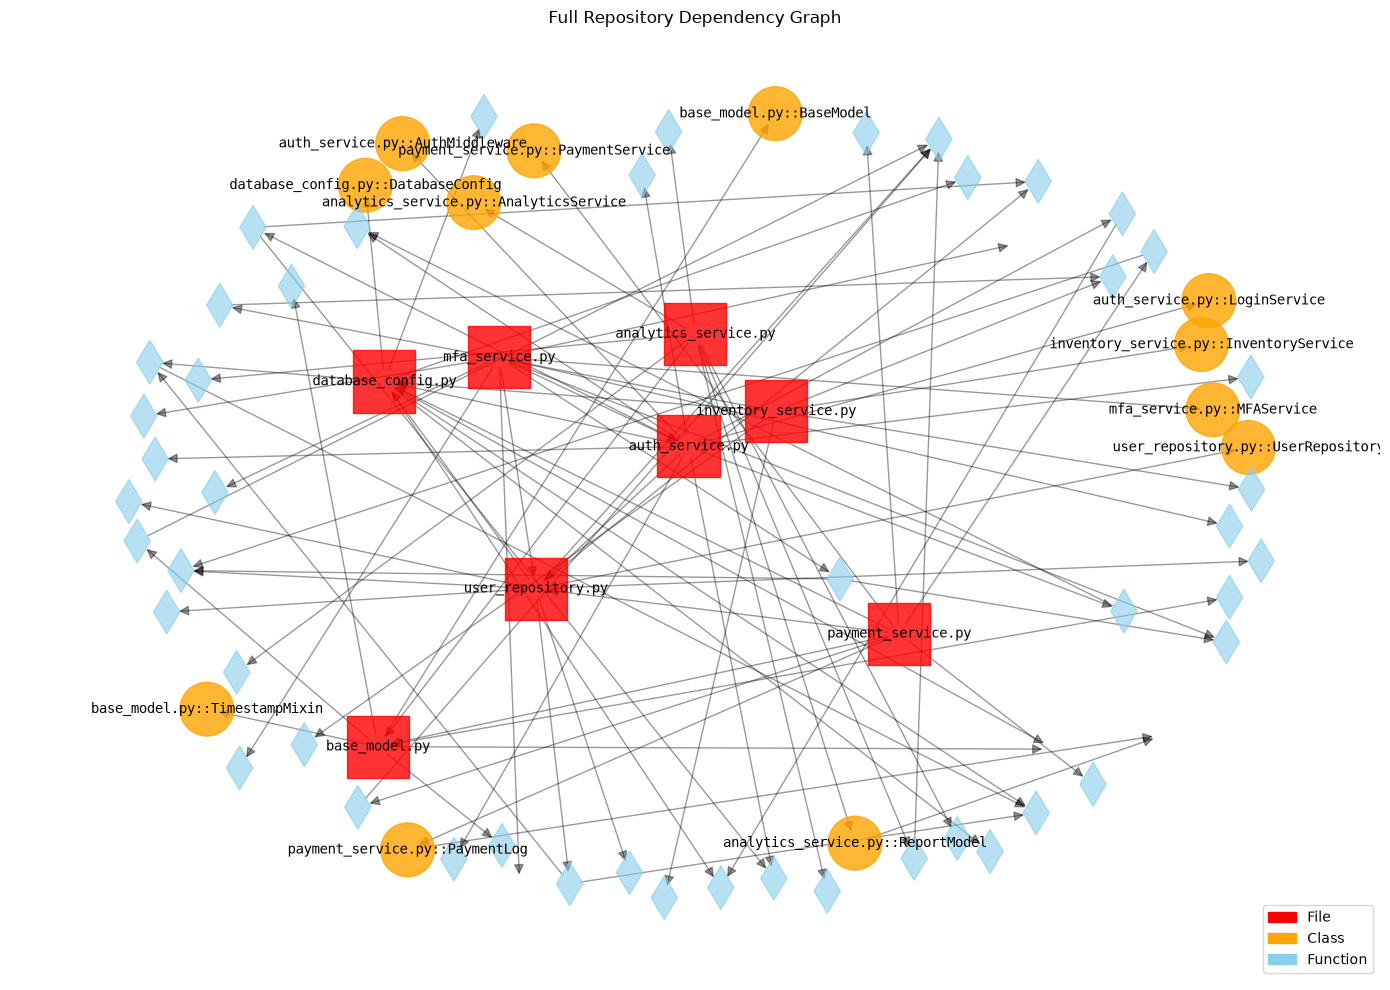


Nodes: 76
Edges: 90
  File nodes: 8
  Class nodes: 12
  Function nodes: 48


In [12]:
# -----------------------------
# Step 3: Visualize full dependency graph
# -----------------------------

plt.figure(figsize=(14, 10))

# Better layout (more spacing)
pos = nx.spring_layout(graph.graph, k=1.5, seed=42)

# Color nodes by type
color_map = []
for node_id in graph.graph.nodes():
    node_type = graph.graph.nodes[node_id].get("node_type", "function")
    if node_type == "file":
        color_map.append("red")
    elif node_type == "class":
        color_map.append("orange")
    else:
        color_map.append("skyblue")

# Draw nodes by type for better visualization
file_nodes_list = [n for n in graph.graph.nodes() if graph.graph.nodes[n].get("node_type") == "file"]
class_nodes_list = [n for n in graph.graph.nodes() if graph.graph.nodes[n].get("node_type") == "class"]
func_nodes_list = [n for n in graph.graph.nodes() if graph.graph.nodes[n].get("node_type") == "function"]

nx.draw_networkx_nodes(
    graph.graph, pos,
    nodelist=file_nodes_list,
    node_color=["red" for _ in file_nodes_list],
    node_size=2000,
    node_shape="s",
    alpha=0.8,
)

nx.draw_networkx_nodes(
    graph.graph, pos,
    nodelist=class_nodes_list,
    node_color=["orange" for _ in class_nodes_list],
    node_size=1500,
    node_shape="o",
    alpha=0.8,
)

nx.draw_networkx_nodes(
    graph.graph, pos,
    nodelist=func_nodes_list,
    node_color=["skyblue" for _ in func_nodes_list],
    node_size=500,
    node_shape="d",
    alpha=0.6,
)

nx.draw_networkx_edges(
    graph.graph, pos,
    arrows=True,
    arrowsize=15,
    alpha=0.4,
)

# Draw labels for file nodes only (keep it readable)
file_labels = {n: n for n in file_nodes_list}
nx.draw_networkx_labels(
    graph.graph, pos,
    labels=file_labels,
    font_size=10,
    font_family="monospace",
)

class_labels = {n: n for n in class_nodes_list}
nx.draw_networkx_labels(
    graph.graph, pos,
    labels=class_labels,
    font_size=10,
    font_family="monospace",
)


plt.title("Full Repository Dependency Graph")
plt.axis("off")
file_patch = mpatches.Patch(color='red', label='File')
class_patch = mpatches.Patch(color='orange', label='Class')
func_patch = mpatches.Patch(color='skyblue', label='Function')
plt.legend(handles=[file_patch, class_patch, func_patch], loc='lower right')
plt.tight_layout()
plt.show()

print(f"\nNodes: {graph.node_count}")
print(f"Edges: {graph.edge_count}")
print(f"  File nodes: {len(file_nodes_list)}")
print(f"  Class nodes: {len(class_nodes_list)}")
print(f"  Function nodes: {len(func_nodes_list)}")

In [13]:
# -----------------------------
# Step 4: Run baseline BFS and ACCS with multiple queries
# -----------------------------

TOKEN_BUDGET = 500
MAX_DEPTH = 5
TOP_K = 3

queries = [
    "How does auth works?",
    "How are payments processed?",
    "How is user data stored?",
    "How is MFA implemented?",
]

# Storage for all results
all_results = {}

for q in queries:
    print(f"\n{'='*60}")
    print(f"Query: {q}")
    print(f"{'='*60}\n")

    # Find start nodes
    matches = GraphSearch.search(graph, q)
    start_nodes = GraphSearch.find_start_nodes(graph, q, top_k=TOP_K)

    if not start_nodes:
        print(f"  No matches found for query")
        all_results[q] = None
        continue

    print(f"  Found {len(start_nodes)} start node(s):")
    for i, sn in enumerate(start_nodes[:TOP_K]):
        node = graph.get_node_data(sn)
        node_type = node.node_type if node else "unknown"
        print(f"    {i+1}. [{node_type}] {sn}")

    # Baseline BFS
    baseline = BaselineBFS(graph, max_depth=MAX_DEPTH)
    baseline_result = baseline.retrieve(q, top_k=TOP_K)
    baseline_nodes = set(baseline_result.retrieved_nodes)
    baseline_tokens = baseline_result.token_estimate.total_tokens
    baseline_coverage = DependencyCoverage.calculate(graph, start_nodes, baseline_nodes)

    # Adaptive ACCS
    adaptive = AdaptiveBudgetRetriever(
        graph,
        budget=TOKEN_BUDGET,
        max_depth=MAX_DEPTH,
        importance_metric="pagerank",
        force_entry_node=False,
        tokenizer_mode="fast",
        scoring_config=ScoringConfig(None),
    )
    adaptive_result = adaptive.retrieve(q, top_k=TOP_K)
    adaptive_nodes = set(adaptive_result.retrieved_nodes)
    adaptive_tokens = adaptive_result.token_estimate.total_tokens
    adaptive_coverage = DependencyCoverage.calculate(graph, start_nodes, adaptive_nodes)

    baseline_cov_ratio = baseline_coverage.coverage_ratio if baseline_coverage else 0
    adaptive_cov_ratio = adaptive_coverage.coverage_ratio if adaptive_coverage else 0
    baseline_missing = len(baseline_coverage.missing_nodes) if baseline_coverage else 0
    adaptive_missing = len(adaptive_coverage.missing_nodes) if adaptive_coverage else 0

    all_results[q] = {
        "start_nodes": start_nodes,
        "baseline_nodes": baseline_nodes,
        "baseline_tokens": baseline_tokens,
        "baseline_coverage": baseline_cov_ratio,
        "baseline_missing": baseline_missing,
        "adaptive_nodes": adaptive_nodes,
        "adaptive_tokens": adaptive_tokens,
        "adaptive_coverage": adaptive_cov_ratio,
        "adaptive_missing": adaptive_missing,
    }

    print(f"\n  Baseline: {len(baseline_nodes)} nodes, {baseline_tokens} tokens, {baseline_cov_ratio:.2%} coverage")
    print(f"  ACCS:     {len(adaptive_nodes)} nodes, {adaptive_tokens} tokens, {adaptive_cov_ratio:.2%} coverage")

    if baseline_tokens > 0:
        reduction = (1 - adaptive_tokens / baseline_tokens) * 100
        print(f"  Reduction: {reduction:.1f}%")

# Store for later cells
first_query = queries[0]
if all_results.get(first_query):
    start_nodes = all_results[first_query]["start_nodes"]
    baseline_nodes = all_results[first_query]["baseline_nodes"]
    adaptive_nodes = all_results[first_query]["adaptive_nodes"]
    baseline_tokens = all_results[first_query]["baseline_tokens"]
    adaptive_tokens = all_results[first_query]["adaptive_tokens"]
    baseline_cov_ratio = all_results[first_query]["baseline_coverage"]
    adaptive_cov_ratio = all_results[first_query]["adaptive_coverage"]
    baseline_missing = all_results[first_query]["baseline_missing"]
    adaptive_missing = all_results[first_query]["adaptive_missing"]
else:
    print("No results loaded!")
    start_nodes = []
    baseline_nodes = set()
    adaptive_nodes = set()
    baseline_tokens = 0
    adaptive_tokens = 0
    baseline_cov_ratio = 0
    adaptive_cov_ratio = 0
    baseline_missing = 0
    adaptive_missing = 0



Query: How does auth works?

  Found 3 start node(s):
    1. [file] auth_service.py
    2. [class] auth_service.py::AuthMiddleware
    3. [function] auth_service.py::authenticate

  Baseline: 31 nodes, 1322.0 tokens, 100.00% coverage
  ACCS:     4 nodes, 353.0 tokens, 33.33% coverage
  Reduction: 73.3%

Query: How are payments processed?

  Found 2 start node(s):
    1. [class] auth_service.py::AuthMiddleware
    2. [class] payment_service.py::PaymentService

  Baseline: 2 nodes, 446.0 tokens, 100.00% coverage
  ACCS:     2 nodes, 446.0 tokens, 100.00% coverage
  Reduction: 0.0%

Query: How is user data stored?

  Found 3 start node(s):
    1. [file] user_repository.py
    2. [function] database_config.py::is_connected
    3. [class] user_repository.py::UserRepository

  Baseline: 19 nodes, 685.0 tokens, 100.00% coverage
  ACCS:     12 nodes, 486.0 tokens, 60.00% coverage
  Reduction: 29.1%

Query: How is MFA implemented?

  Found 3 start node(s):
    1. [function] mfa_service.py::dis

In [14]:
# -----------------------------
# Step 5: Compare results across all queries
# -----------------------------

print("\n" + "="*80)
print("  COMPARISON RESULTS ACROSS ALL QUERIES")
print("="*80)

# Filter to valid queries only
valid_queries = [q for q in queries if all_results.get(q) is not None]

if not valid_queries:
    print("\nNo results to compare")
else:
    # Print table headers
    print(f"\n{'Query':<35} {'Baseline':>10} {'ACCS':>10} {'Reduction':>12} {'Coverage':>12}")
    print("-"*80)

    baseline_tokens_list = []
    adaptive_tokens_list = []
    baseline_cov_list = []
    adaptive_cov_list = []

    for q in valid_queries:
        r = all_results[q]
        
        bt = r["baseline_tokens"]
        at = r["adaptive_tokens"]
        bc = r["baseline_coverage"]
        ac = r["adaptive_coverage"]
        
        reduction = (1 - at / bt) * 100 if bt > 0 else 0
        
        print(f"{q:<35} {bt:>10.0f} {at:>10.0f} {reduction:>11.1f}% {bc:.0%}→{ac:.0%}")
        
        baseline_tokens_list.append(bt)
        adaptive_tokens_list.append(at)
        baseline_cov_list.append(bc)
        adaptive_cov_list.append(ac)

    # Summary
    avg_baseline = sum(baseline_tokens_list) / len(baseline_tokens_list) if baseline_tokens_list else 0
    avg_adaptive = sum(adaptive_tokens_list) / len(adaptive_tokens_list) if adaptive_tokens_list else 0
    avg_reduction = (1 - avg_adaptive / avg_baseline) * 100 if avg_baseline > 0 else 0
    avg_baseline_cov = sum(baseline_cov_list) / len(baseline_cov_list) if baseline_cov_list else 0
    avg_adaptive_cov = sum(adaptive_cov_list) / len(adaptive_cov_list) if adaptive_cov_list else 0

    print("\n" + "-"*80)
    print(f"{'AVERAGE':<35} {avg_baseline:<10.0f} {avg_adaptive:<10.0f} {avg_reduction:<11.1f}% {avg_baseline_cov:.0%}→{avg_adaptive_cov:.0%}")
    print("-"*80)

    # CCR summary
    total_baseline = sum(baseline_tokens_list)
    total_adaptive = sum(adaptive_tokens_list)
    if total_baseline > 0:
        ccr = total_adaptive / total_baseline
        total_reduction = (1 - ccr) * 100
        print(f"\nOverall Context Compression Ratio (CCR): {ccr:.2f}")
        print(f"Total token reduction: {total_reduction:.1f}% ({total_baseline:.0f} → {total_adaptive:.0f} tokens)")

# Store for later cells using first valid query
if valid_queries:
    first_valid = valid_queries[0]
    r = all_results[first_valid]
    start_nodes = r["start_nodes"]
    baseline_nodes = r["baseline_nodes"]
    adaptive_nodes = r["adaptive_nodes"]
    baseline_tokens = r["baseline_tokens"]
    adaptive_tokens = r["adaptive_tokens"]
    baseline_cov_ratio = r["baseline_coverage"]
    adaptive_cov_ratio = r["adaptive_coverage"]
    baseline_missing = r["baseline_missing"]
    adaptive_missing = r["adaptive_missing"]
    display_query = first_valid
else:
    print("No results loaded!")
    start_nodes = []
    baseline_nodes = set()
    adaptive_nodes = set()
    baseline_tokens = 0
    adaptive_tokens = 0
    baseline_cov_ratio = 0
    adaptive_cov_ratio = 0
    baseline_missing = 0
    adaptive_missing = 0
    display_query = queries[0] if queries else ""

print(
    "\nNote: The per-query average reduction is the arithmetic mean of "
    "individual query reductions. The overall reduction is calculated "
    "from total baseline and ACCS tokens and therefore weights queries "
    "according to their token usage."
)


  COMPARISON RESULTS ACROSS ALL QUERIES

Query                                 Baseline       ACCS    Reduction     Coverage
--------------------------------------------------------------------------------
How does auth works?                      1322        353        73.3% 100%→33%
How are payments processed?                446        446         0.0% 100%→100%
How is user data stored?                   685        486        29.1% 100%→60%
How is MFA implemented?                   1738        416        76.1% 100%→33%

--------------------------------------------------------------------------------
AVERAGE                             1048       425        59.4       % 100%→57%
--------------------------------------------------------------------------------

Overall Context Compression Ratio (CCR): 0.41
Total token reduction: 59.4% (4191 → 1701 tokens)

Note: The per-query average reduction is the arithmetic mean of individual query reductions. The overall reduction is calculated fr

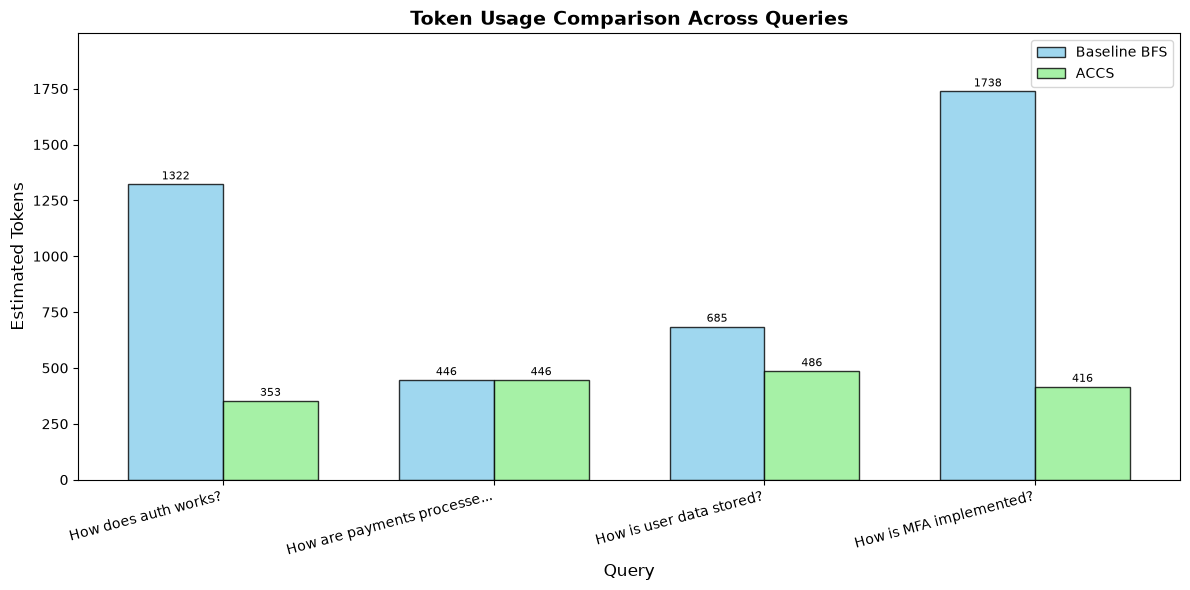

In [15]:
# -----------------------------
# Step 6: Visualize token comparison across all queries
# -----------------------------

# Filter to only queries with results
valid_queries = [q for q in queries if all_results.get(q) is not None]
valid_baseline = [all_results[q]["baseline_tokens"] for q in valid_queries]
valid_adaptive = [all_results[q]["adaptive_tokens"] for q in valid_queries]
valid_labels = [q[:25] + "..." if len(q) > 25 else q for q in valid_queries]
x = range(len(valid_queries))

if not valid_queries:
    print("No results to plot")
else:
    fig, ax = plt.subplots(figsize=(12, 6))
    width = 0.35

    bars1 = ax.bar([i - width/2 for i in x], valid_baseline,
                   width, label='Baseline BFS', color='skyblue', edgecolor='black', alpha=0.8)
    bars2 = ax.bar([i + width/2 for i in x], valid_adaptive,
                   width, label='ACCS', color='lightgreen', edgecolor='black', alpha=0.8)

    # Add value labels
    for bar, val in zip(bars1, valid_baseline):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                    f"{val:.0f}", ha='center', va='bottom', fontsize=8)
    for bar, val in zip(bars2, valid_adaptive):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                    f"{val:.0f}", ha='center', va='bottom', fontsize=8)

    ax.set_title("Token Usage Comparison Across Queries", fontsize=14, fontweight='bold')
    ax.set_xlabel("Query", fontsize=12)
    ax.set_ylabel("Estimated Tokens", fontsize=12)
    ax.set_xticks(list(x))
    ax.set_xticklabels(valid_labels, rotation=15, ha='right')
    ax.legend()
    ax.set_ylim(0, max(max(valid_baseline), max(valid_adaptive)) * 1.15)
    plt.tight_layout()
    plt.show()


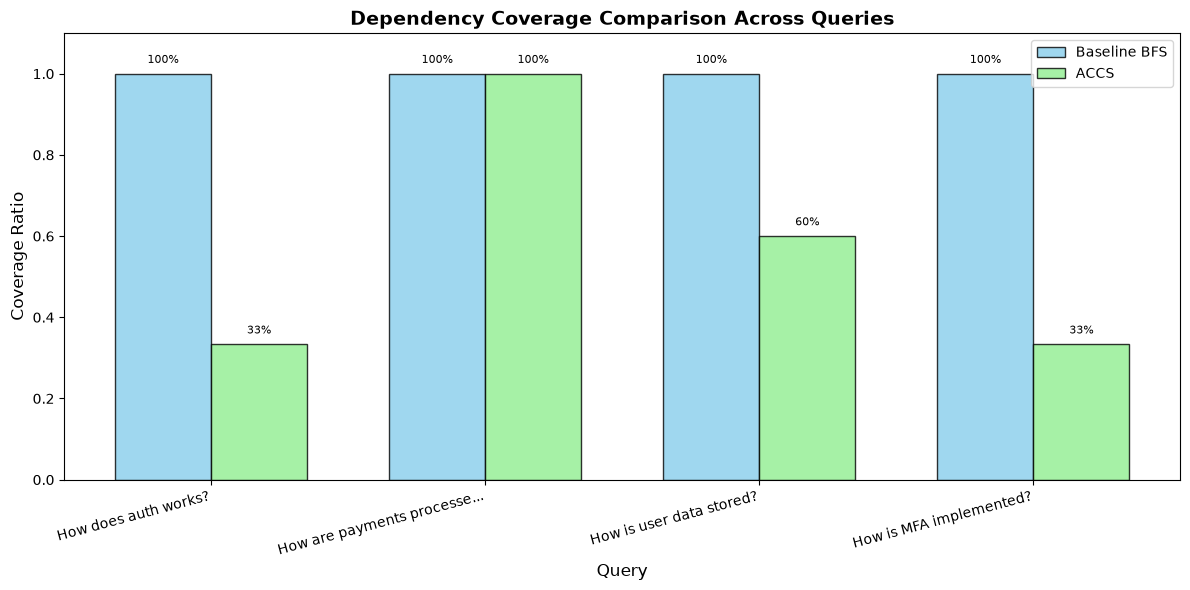

In [16]:
# -----------------------------
# Step 7: Visualize coverage comparison across all queries
# -----------------------------

if not valid_queries:
    print("No results to plot")
else:
    valid_cov_baseline = [all_results[q]["baseline_coverage"] for q in valid_queries]
    valid_cov_adaptive = [all_results[q]["adaptive_coverage"] for q in valid_queries]

    fig, ax = plt.subplots(figsize=(12, 6))
    width = 0.35

    bars1 = ax.bar([i - width/2 for i in x], valid_cov_baseline,
                   width, label='Baseline BFS', color='skyblue', edgecolor='black', alpha=0.8)
    bars2 = ax.bar([i + width/2 for i in x], valid_cov_adaptive,
                   width, label='ACCS', color='lightgreen', edgecolor='black', alpha=0.8)

    # Add value labels
    for bar, val in zip(bars1, valid_cov_baseline):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{val:.0%}", ha='center', va='bottom', fontsize=8)
    for bar, val in zip(bars2, valid_cov_adaptive):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{val:.0%}", ha='center', va='bottom', fontsize=8)

    ax.set_title("Dependency Coverage Comparison Across Queries", fontsize=14, fontweight='bold')
    ax.set_xlabel("Query", fontsize=12)
    ax.set_ylabel("Coverage Ratio", fontsize=12)
    ax.set_xticks(list(x))
    ax.set_xticklabels(valid_labels, rotation=15, ha='right')
    ax.legend()
    ax.set_ylim(0, 1.1)
    plt.tight_layout()
    plt.show()


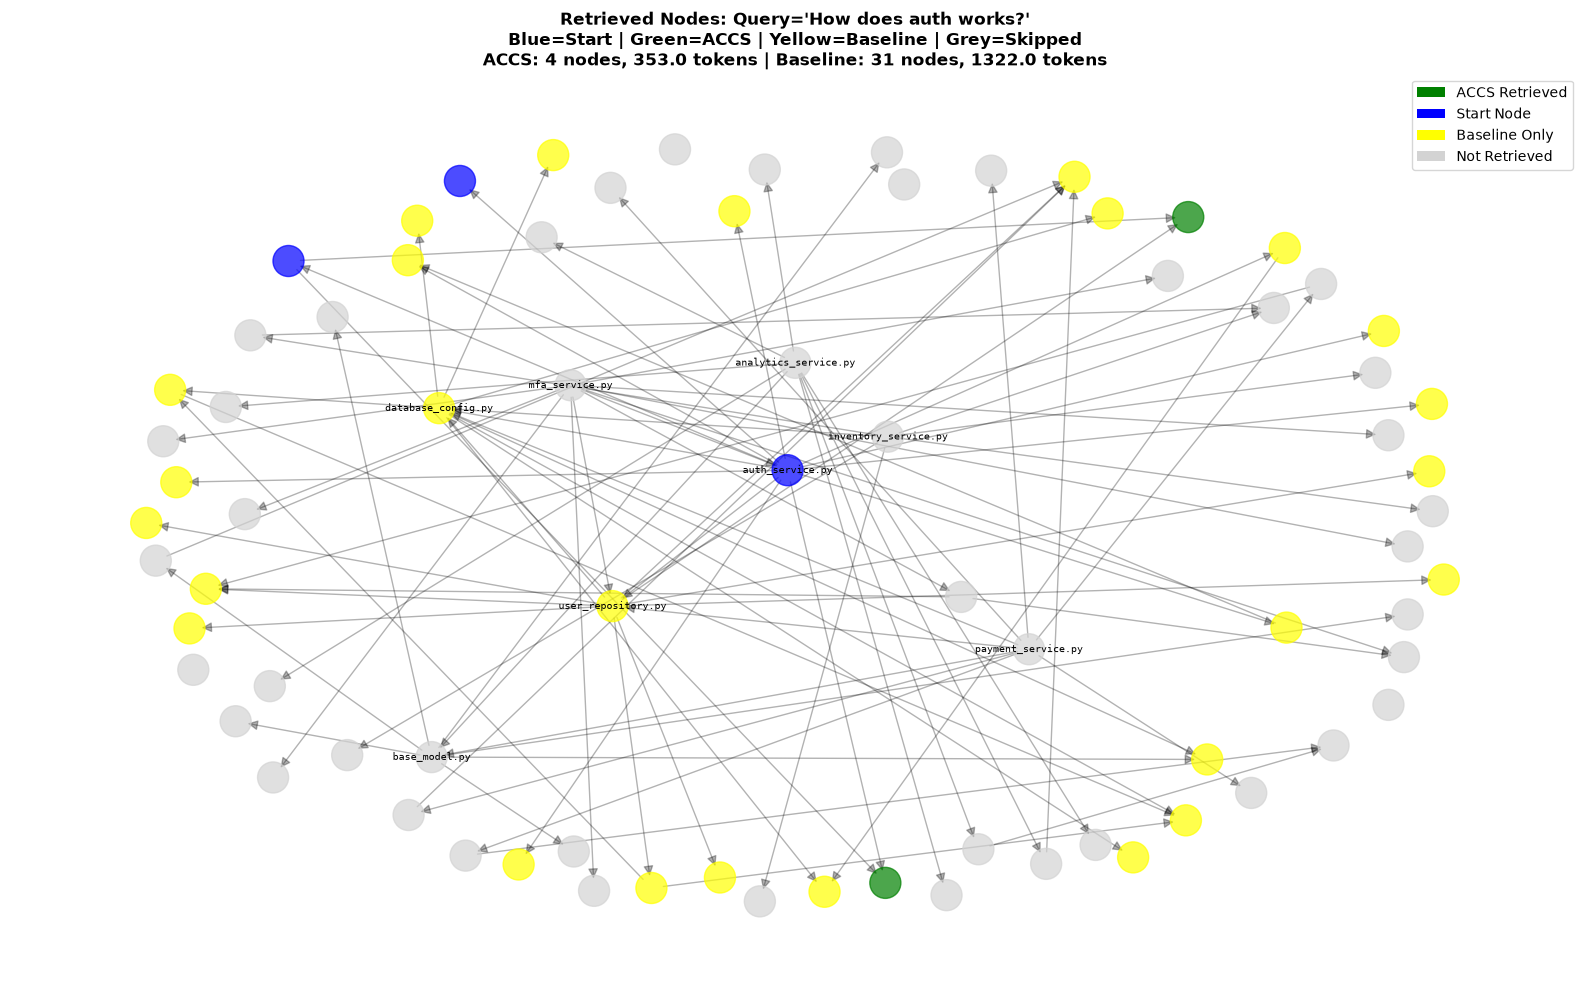

In [17]:
# -----------------------------
# Step 8: Visualize retrieved nodes on graph (first query)
# -----------------------------

display_result = all_results.get(display_query)

if not display_result:
    print("No results for first query")
else:
    dn = display_result["baseline_nodes"]
    an = display_result["adaptive_nodes"]
    dt = display_result["baseline_tokens"]
    at = display_result["adaptive_tokens"]

    plt.figure(figsize=(16, 10))
    pos = nx.spring_layout(graph.graph, k=1.5, seed=42)

    nodes_list = list(graph.graph.nodes())
    node_color_map = {}
    for sn in start_nodes:
        node_color_map[sn] = 'blue'
    for n in an:
        if n not in node_color_map:
            node_color_map[n] = 'green'
    for n in dn:
        if n not in node_color_map:
            node_color_map[n] = 'yellow'
    for n in nodes_list:
        if n not in node_color_map:
            node_color_map[n] = 'lightgrey'

    final_colors = [node_color_map.get(n, 'lightgrey') for n in nodes_list]

    nx.draw_networkx_nodes(
        graph.graph, pos,
        nodelist=nodes_list,
        node_color=final_colors,
        node_size=500,
        alpha=0.7,
    )

    nx.draw_networkx_edges(
        graph.graph, pos,
        arrows=True,
        arrowsize=15,
        alpha=0.3,
    )

    file_nodes_list = [n for n in graph.graph.nodes() if graph.graph.nodes[n].get('node_type') == 'file']
    file_labels = {n: n for n in file_nodes_list}
    nx.draw_networkx_labels(
        graph.graph, pos,
        labels=file_labels,
        font_size=7,
        font_family='monospace',
    )

    plt.title(
        f"Retrieved Nodes: Query='{display_query}'\n"
        f"Blue=Start | Green=ACCS | Yellow=Baseline | Grey=Skipped\n"
        f"ACCS: {len(an)} nodes, {at} tokens | Baseline: {len(dn)} nodes, {dt} tokens",
        fontsize=12, fontweight='bold'
    )
    plt.axis('off')

    legend_elements = [
        mpatches.Patch(facecolor='green', label='ACCS Retrieved'),
        mpatches.Patch(facecolor='blue', label='Start Node'),
        mpatches.Patch(facecolor='yellow', label='Baseline Only'),
        mpatches.Patch(facecolor='lightgrey', label='Not Retrieved'),
    ]
    plt.legend(handles=legend_elements, loc='upper right', fontsize=10)
    plt.tight_layout()
    plt.show()


In [18]:
# -----------------------------
# Step 9: Show retrieved context for first query
# -----------------------------

display_result = all_results.get(display_query)

if not display_result:
    print("No results for first query")
else:
    display_adaptive_nodes = display_result["adaptive_nodes"]
    display_adaptive_tokens = display_result["adaptive_tokens"]
    display_adaptive_cov = display_result["adaptive_coverage"]
    display_adaptive_missing = display_result["adaptive_missing"]

    # Build context
    adaptive = AdaptiveBudgetRetriever(
        graph,
        budget=TOKEN_BUDGET,
        max_depth=MAX_DEPTH,
        importance_metric="pagerank",
        force_entry_node=False,
        tokenizer_mode="fast",
        scoring_config=ScoringConfig(None),
    )
    adaptive_result = adaptive.retrieve(display_query, top_k=TOP_K)
    
    context_builder = ContextBuilder(tokenizer_mode="fast")
    adaptive_context = context_builder.build(list(display_adaptive_nodes), graph)

    print("="*60)
    print("ADAPTIVE RETRIEVAL - Context Summary")
    print("="*60)
    print(f"Query: {display_query}")
    print(f"Budget: {TOKEN_BUDGET} tokens")
    print(f"Tokens used: {display_adaptive_tokens}")
    print(f"Nodes retrieved: {len(display_adaptive_nodes)}")
    print(f"Coverage: {display_adaptive_cov:.2%}")
    print(f"Missing nodes: {display_adaptive_missing}")
    print()

    # Show retrieved files
    print("Retrieved files:")
    for node_id in sorted(display_adaptive_nodes):
        node = graph.get_node_data(node_id)
        if node:
            print(f"  - [{node.node_type}] {node_id} (~{node.estimated_token_cost} tokens)")

    # Show context snippet
    print()
    print("Context preview (first 1500 chars):")
    print("-"*60)
    context_preview = adaptive_context.source[:1500]
    print(context_preview)
    if len(adaptive_context.source) > 1500:
        print(f"\n... ({len(adaptive_context.source)} total chars)")


ADAPTIVE RETRIEVAL - Context Summary
Query: How does auth works?
Budget: 500 tokens
Tokens used: 353.0
Nodes retrieved: 4
Coverage: 33.33%
Missing nodes: 4

Retrieved files:
  - [class] auth_service.py::AuthMiddleware (~168 tokens)
  - [function] auth_service.py::_generate_token (~58 tokens)
  - [function] auth_service.py::authenticate (~88 tokens)
  - [function] user_repository.py::find_by_email (~39 tokens)

Context preview (first 1500 chars):
------------------------------------------------------------
--- auth_service.py ---
# class: AuthMiddleware (lines 6-23)
class AuthMiddleware:
    """Middleware for authentication requests."""

    def __init__(self, auth_service: 'LoginService'):
        self.auth_service = auth_service

    def process_request(self, request: dict) -> dict:
        """Process an incoming authentication request."""
        token = request.get("token")
        if token:
            return self.auth_service.validate_token(token)
        return {"status": "unauth

In [19]:
# -----------------------------
# Step 10: Comprehensive analysis across all queries
# -----------------------------

# Filter to valid queries only
valid_results = {q: r for q, r in all_results.items() if q in valid_queries and r is not None}

print("\n" + "="*80)
print("  COMPREHENSIVE ANALYSIS: Multiple Query Evaluation")
print("="*80)

if not valid_results:
    print("No valid results to analyze")
else:
    print(f"\nTotal queries evaluated: {len(valid_results)}/{len(queries)}")

    print("\n### Token Usage Summary")
    print("-"*80)
    print(f"{'Query':<35} {'Baseline':>10} {'ACCS':>10} {'Reduction':>10}")
    print("-"*80)

    reductions = []
    for q in valid_queries:
        r = valid_results[q]
        bt = r["baseline_tokens"]
        at = r["adaptive_tokens"]
        reduction = (1 - at / bt) * 100 if bt > 0 else 0
        reductions.append(reduction)
        print(f"{q:<35} {bt:>10.0f} {at:>10.0f} {reduction:>9.1f}%")

    avg_reduction = sum(reductions) / len(reductions) if reductions else 0
    print("-"*80)
    print(f"{'Average':<35} {'':>10} {'':>10} {avg_reduction:>9.1f}%")

    print("\n### Coverage Trade-off Summary")
    print("-"*80)
    print(f"{'Query':<35} {'Baseline':>10} {'ACCS':>10} {'Delta':>10}")
    print("-"*80)

    for q in valid_queries:
        r = valid_results[q]
        bc = r["baseline_coverage"]
        ac = r["adaptive_coverage"]
        delta = (ac - bc) * 100
        print(f"{q:<35} {bc:>9.0%} {ac:>10.0%} {delta:>+9.1f}%")

    # Key findings
    total_baseline = sum(r["baseline_tokens"] for r in valid_results.values())
    total_adaptive = sum(r["adaptive_tokens"] for r in valid_results.values())
    total_baseline_cov = sum(r["baseline_coverage"] for r in valid_results.values()) / len(valid_results)
    total_adaptive_cov = sum(r["adaptive_coverage"] for r in valid_results.values()) / len(valid_results)
    overall_ccr = total_adaptive / total_baseline if total_baseline > 0 else 0
    overall_reduction = (1 - overall_ccr) * 100

    print("\n" + "="*80)
    print("  KEY FINDINGS")
    print("="*80)
    print(f"\n1. Overall Token Reduction: {overall_reduction:.1f}% ({total_baseline:.0f} → {total_adaptive:.0f} tokens)")
    print(f"2. Context Compression Ratio (CCR): {overall_ccr:.2f}")
    print(f"3. Average Coverage: Baseline {total_baseline_cov:.0%} → ACCS {total_adaptive_cov:.0%}")
    print(f"4. Queries where ACCS reduced tokens: {sum(1 for r in valid_results.values() if r['adaptive_tokens'] < r['baseline_tokens'])}/{len(valid_results)}")

    print("\n### Complexity Analysis")
    print("-"*80)
    print("Baseline BFS: O(V + E), where V is the number of graph nodes and E is the number of dependency edges.\n\nACCS: ACCS performs graph-based importance scoring followed by budget-aware priority selection. The priority queue operations require O(log V) per insertion, while the PageRank importance calculation is iterative and depends on the graph size and number of iterations.\n\nTherefore, the exact ACCS complexity depends on the selected importance metric. With PageRank, the algorithm introduces additional graph-scoring overhead compared with BFS.\n\nThe additional retrieval-time computation is traded for reduced context size sent to the downstream LLM.")

    print("\n### Budget Effectiveness")
    print("-"*80)
    under_budget = sum(1 for r in valid_results.values() if r["adaptive_tokens"] <= TOKEN_BUDGET)
    over_budget = sum(1 for r in valid_results.values() if r["adaptive_tokens"] > TOKEN_BUDGET)
    print(f"Queries within budget ({TOKEN_BUDGET}): {under_budget}/{len(valid_results)}")
    print(f"Queries exceeding budget: {over_budget}/{len(valid_results)}")

    # Save results as JSON
    import json as json_module
    results_export = {
        "queries": queries,
        "budget": TOKEN_BUDGET,
        "results": {},
        "summary": {
            "total_queries": len(valid_results),
            "overall_token_reduction_pct": round(overall_reduction, 1),
            "overall_ccr": round(overall_ccr, 2),
            "total_baseline_tokens": round(total_baseline),
            "total_adaptive_tokens": round(total_adaptive),
        }
    }
    for q in valid_results:
        r = valid_results[q]
        results_export["results"][q] = {
            "start_nodes": r["start_nodes"],
            "baseline_nodes": list(r["baseline_nodes"]),
            "baseline_tokens": r["baseline_tokens"],
            "baseline_coverage": r["baseline_coverage"],
            "baseline_missing": r["baseline_missing"],
            "adaptive_nodes": list(r["adaptive_nodes"]),
            "adaptive_tokens": r["adaptive_tokens"],
            "adaptive_coverage": r["adaptive_coverage"],
            "adaptive_missing": r["adaptive_missing"],
        }

    results_path = PROJECT_ROOT / "evaluation_results.json"

    results_path.write_text(json_module.dumps(results_export, indent=2))
    print(f"\n✓ Full results saved to: {results_path}")



  COMPREHENSIVE ANALYSIS: Multiple Query Evaluation

Total queries evaluated: 4/4

### Token Usage Summary
--------------------------------------------------------------------------------
Query                                 Baseline       ACCS  Reduction
--------------------------------------------------------------------------------
How does auth works?                      1322        353      73.3%
How are payments processed?                446        446       0.0%
How is user data stored?                   685        486      29.1%
How is MFA implemented?                   1738        416      76.1%
--------------------------------------------------------------------------------
Average                                                        44.6%

### Coverage Trade-off Summary
--------------------------------------------------------------------------------
Query                                 Baseline       ACCS      Delta
-----------------------------------------------------

# -----------------------------
# Step 11: Coverage Retention Trade-off Analysis
# -----------------------------

This section adds a key trade-off metric: **Coverage Retained** — what percentage of the baseline coverage does ACCS maintain for each query.

Formula: `coverage_retention = adaptive_cov / baseline_cov`

- **100% retention**: ACCS captures all baseline coverage (ideal)
- **<100% retention**: Some baseline coverage is sacrificed for token savings

In [20]:
# Calculate coverage retention for each query
import metrics


print("="*80)
print("  COVERAGE RETENTION TRADE-OFF ANALYSIS")
print("="*80)

print(f"\n{'Query':<35} {'Tokens':>14} {'Coverage':>14} {'Retained':>10} {'Token':>8} {'Tokens / Coverage Point':>8}")
print(f"{'':>40} {'Saved':>7} {'Cover%':>7}")
print("-"*80)

retention_values = []
cost_per_point_values = []

for q in valid_queries:
    r = all_results[q]
    baseline_cov = r["baseline_coverage"]
    adaptive_cov = r["adaptive_coverage"]
    baseline_tok = r["baseline_tokens"]
    adaptive_tok = r["adaptive_tokens"]
    
    # Coverage retention: how much of baseline coverage does ACCS retain?
    if baseline_cov > 0:
        retention = (adaptive_cov / baseline_cov) * 100
    else:
        retention = 100.0
    
    tokens_saved = baseline_tok - adaptive_tok
    
    # Cost per coverage point: how many tokens do we spend per 1% of coverage?
    if adaptive_cov > 0:
        cost_per_point = adaptive_tok / (adaptive_cov * 100)
    else:
        cost_per_point = float('inf')
    
    retention_values.append(retention)
    cost_per_point_values.append(cost_per_point)
    
    print(f"{q:<35} {baseline_tok:>4}/{adaptive_tok:<4} {baseline_cov:.0%}/{adaptive_cov:.0%} {retention:>9.1f}% {tokens_saved:>7.0f} {cost_per_point:>7.1f}")

avg_retention = sum(retention_values) / len(retention_values) if retention_values else 0
avg_cost_per_point = sum(cost_per_point_values) / len(cost_per_point_values) if cost_per_point_values else 0
total_baseline_tokens = sum(all_results[q]["baseline_tokens"] for q in valid_queries)
total_adaptive_tokens = sum(all_results[q]["adaptive_tokens"] for q in valid_queries)
total_tokens_saved = total_baseline_tokens - total_adaptive_tokens

print("-"*80)
avg_baseline = total_baseline_tokens / len(valid_queries)
avg_adaptive = total_adaptive_tokens / len(valid_queries)
avg_baseline_cov = sum(all_results[q]["baseline_coverage"] for q in valid_queries) / len(valid_queries) * 100
avg_adaptive_cov = sum(all_results[q]["adaptive_coverage"] for q in valid_queries) / len(valid_queries) * 100
print(f"{'AVERAGE':<35} {avg_baseline:<10.0f}/{avg_adaptive:<4.0f} {avg_baseline_cov:.0f}%/{avg_adaptive_cov:.0f}%   {avg_retention:>9.1f}% {total_tokens_saved:<7.0f} {avg_cost_per_point:>7.1f}")
print("-"*80)

print("\nInterpretation:")
print("Coverage retention indicates how much of the baseline dependency")
print("coverage is maintained by ACCS. Lower retention indicates a larger")
print("coverage sacrifice in exchange for reduced context cost.")

print("\nCost per % Coverage point:")
for q in valid_queries:
    r = all_results[q]
    if r["adaptive_coverage"] > 0:
        cpp = r["adaptive_tokens"] / (r["adaptive_coverage"] * 100)
        print(f"  - {q.split('?')[0].strip()}: {cpp:.1f} tokens per 1% coverage")

print("\nACCS substantially reduces context cost for Authentication and MFA,")
print("saving approximately 73–76% of tokens, but this is accompanied by a")
print("substantial reduction in dependency coverage to approximately 33%.")
print("The results therefore demonstrate a cost–coverage trade-off rather")
print("than an improvement in both metrics simultaneously.")


  COVERAGE RETENTION TRADE-OFF ANALYSIS

Query                                       Tokens       Coverage   Retained    Token Tokens / Coverage Point
                                           Saved  Cover%
--------------------------------------------------------------------------------
How does auth works?                1322.0/353.0 100%/33%      33.3%     969    10.6
How are payments processed?         446.0/446.0 100%/100%     100.0%       0     4.5
How is user data stored?            685.0/486.0 100%/60%      60.0%     199     8.1
How is MFA implemented?             1738.0/416.0 100%/33%      33.3%    1322    12.5
--------------------------------------------------------------------------------
AVERAGE                             1048      /425  100%/57%        56.7% 2490        8.9
--------------------------------------------------------------------------------

Interpretation:
Coverage retention indicates how much of the baseline dependency
coverage is maintained by ACCS. Lower 

# -----------------------------
# Step 12: Budget Sensitivity Testing
# -----------------------------

This section tests how ACCS performs across different token budgets to demonstrate the fundamental behavior of the algorithm:

```
Lower budget → less context → lower cost → potentially lower coverage
Higher budget → more context → higher cost → better coverage
```

This experiment examines how the token budget affects retrieval cost
and dependency coverage. The results are used to identify the observed
cost–coverage trade-off across the tested budget levels.

In [21]:
# Budget sensitivity testing across multiple budget levels
budgets = [250, 350, 500, 750, 1000]
budget_results = {}

print("="*80)
print("  BUDGET SENSITIVITY ANALYSIS")
print("="*80)
print(f"\nTesting budgets: {budgets}")
print(f"Queries evaluated: {len(valid_queries)}")

for budget in budgets:
    budget_tokens = []
    budget_coverage = []
    budget_nodes = []
    
    for q in valid_queries:
        r = all_results[q]
        start_nodes = r["start_nodes"]
        
        # Run ACCS with this specific budget
        adaptive = AdaptiveBudgetRetriever(
            graph,
            budget=budget,
            max_depth=MAX_DEPTH,
            importance_metric="pagerank",
            force_entry_node=False,
            tokenizer_mode="fast",
            scoring_config=ScoringConfig(None),
        )
        result = adaptive.retrieve(q, top_k=TOP_K)
        
        retrieved_nodes = set(result.retrieved_nodes)
        tokens = result.token_estimate.total_tokens
        coverage = DependencyCoverage.calculate(graph, start_nodes, retrieved_nodes)
        
        coverage_ratio = coverage.coverage_ratio if coverage else 0
        
        budget_tokens.append(tokens)
        budget_coverage.append(coverage_ratio)
        budget_nodes.append(len(retrieved_nodes))
    
    budget_results[budget] = {
        "avg_tokens": sum(budget_tokens) / len(budget_tokens),
        "avg_coverage": sum(budget_coverage) / len(budget_coverage),
        "avg_nodes": sum(budget_nodes) / len(budget_nodes),
        "std_coverage": (sum((x - sum(budget_coverage)/len(budget_coverage))**2 for x in budget_coverage) / len(budget_coverage)) ** 0.5,
        "max_tokens": max(budget_tokens),
        "min_tokens": min(budget_tokens),
        "max_coverage": max(budget_coverage),
        "min_coverage": min(budget_coverage),
    }

# Print results table
print(f"\n{'Budget':<10} {'Avg Tokens':>12} {'Avg Coverage':>14} {'Avg Nodes':>12} {'Std Coverage':>14}")
print("-"*80)

for budget in budgets:
    br = budget_results[budget]
    print(f"{budget:<10} {br['avg_tokens']:<12.0f} {br['avg_coverage']:>12.1%} {br['avg_nodes']:<12.1f} {br['std_coverage'] * 100:>12.1f}%")

print("-"*80)

# Calculate coverage deltas between consecutive budgets
print("\nKey Observations:")
for i in range(1, len(budgets)):
    prev_budget = budgets[i-1]
    curr_budget = budgets[i]
    prev_cov = budget_results[prev_budget]["avg_coverage"]
    curr_cov = budget_results[curr_budget]["avg_coverage"]
    gain = (curr_cov - prev_cov) * 100
    print(f"  - Budget {prev_budget}→{curr_budget}: {gain:+.1f}% coverage gain")


print(f"\n✓ Budget sensitivity results saved to: {PROJECT_ROOT / 'budget_sensitivity_results.json'}")

# Save budget sensitivity results
import json as json_module
with open(PROJECT_ROOT / "budget_sensitivity_results.json", "w") as f:
    json_module.dump(budget_results, f, indent=2)


  BUDGET SENSITIVITY ANALYSIS

Testing budgets: [250, 350, 500, 750, 1000]
Queries evaluated: 4

Budget       Avg Tokens   Avg Coverage    Avg Nodes   Std Coverage
--------------------------------------------------------------------------------
250        150                 27.2% 1.8                  13.3%
350        186                 31.4% 2.2                  11.9%
500        425                 56.7% 6.5                  27.3%
750        542                 60.8% 9.5                  24.5%
1000       737                 72.8% 15.0                 20.2%
--------------------------------------------------------------------------------

Key Observations:
  - Budget 250→350: +4.2% coverage gain
  - Budget 350→500: +25.3% coverage gain
  - Budget 500→750: +4.2% coverage gain
  - Budget 750→1000: +11.9% coverage gain

✓ Budget sensitivity results saved to: /home/dilusha/projects/BGCR/budget_sensitivity_results.json


# -----------------------------
# Step 13: Budget Sensitivity Visualization
# -----------------------------

This cell visualizes how coverage and token usage change across different budget levels.

Budget sensitivity plot saved to: budget_sensitivity.png


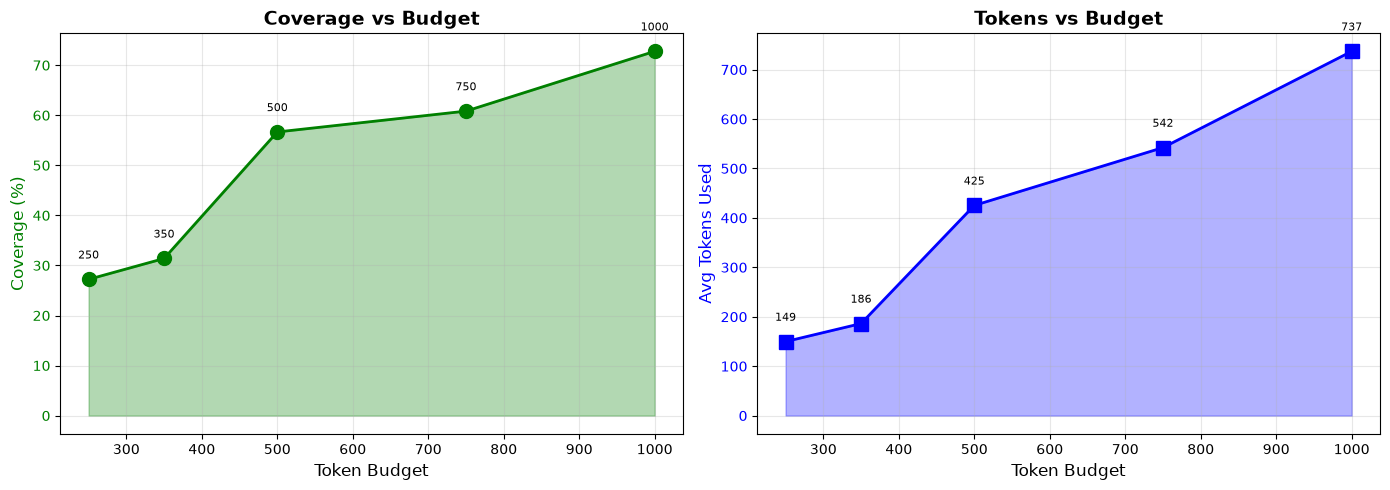

In [22]:
# Plot budget sensitivity
budgets = list(budget_results.keys())
coverage_values = [budget_results[b]["avg_coverage"] * 100 for b in budgets]
tokens_values = [budget_results[b]["avg_tokens"] for b in budgets]
nodes_values = [budget_results[b]["avg_nodes"] for b in budgets]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Coverage vs Budget
ax1.plot(budgets, coverage_values, 'o-', color='green', linewidth=2, markersize=10, label='Coverage')
ax1.fill_between(budgets, coverage_values, alpha=0.3, color='green')
ax1.set_xlabel('Token Budget', fontsize=12)
ax1.set_ylabel('Coverage (%)', fontsize=12, color='green')
ax1.set_title('Coverage vs Budget', fontsize=14, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='green')
ax1.grid(True, alpha=0.3)

# Add budget markers
for i, budget in enumerate(budgets):
    ax1.annotate(f'{budget}', (budget, coverage_values[i]), 
                textcoords='offset points', xytext=(0, 15), ha='center', fontsize=8)

# Tokens vs Budget
ax2.plot(budgets, tokens_values, 's-', color='blue', linewidth=2, markersize=10, label='Tokens')
ax2.fill_between(budgets, tokens_values, alpha=0.3, color='blue')
ax2.set_xlabel('Token Budget', fontsize=12)
ax2.set_ylabel('Avg Tokens Used', fontsize=12, color='blue')
ax2.set_title('Tokens vs Budget', fontsize=14, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.grid(True, alpha=0.3)

# Add token markers
for i, budget in enumerate(budgets):
    ax2.annotate(f'{int(tokens_values[i])}', (budget, tokens_values[i]), 
                textcoords='offset points', xytext=(0, 15), ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'budget_sensitivity.png', dpi=150, bbox_inches='tight')
print("Budget sensitivity plot saved to: budget_sensitivity.png")


# -----------------------------
# Step 14: Equal-Budget BFS vs ACCS Comparison
# -----------------------------

This experiment tests the fundamental question: **given the same budget**, which algorithm delivers better coverage?

**Baseline BFS**: traverses nodes in breadth-first discovery order and includes nodes whenever they fit within the remaining token budget.

**ACCS**: Uses importance scoring (Pagerank) to select the most relevant nodes within the same budget.

This comparison isolates the effect of **node selection strategy** from the total amount of context provided.

In [23]:
# Equal-budget comparison: BFS vs ACCS
BUDGET = 500

print("=" * 80)
print("  EQUAL-BUDGET COMPARISON: BFS vs ACCS")
print("=" * 80)
print(f"\nShared Token Budget: {BUDGET}")
print(f"Queries evaluated: {len(valid_queries)}\n")

equal_budget_results = []

for q in valid_queries:
    r = all_results[q]
    start_nodes = r["start_nodes"]

    # Run baseline BFS to get nodes in BFS order
    baseline = BaselineBFS(graph, max_depth=MAX_DEPTH)
    bfs_result = baseline.retrieve(q, top_k=TOP_K)

    # Use the actual BFS traversal order rather than the retrieved-node set.
    # The set does not preserve the order in which BFS discovered nodes.
    bfs_nodes_ordered = bfs_result.traversal_order
    bfs_budget_nodes = set()
    bfs_budget_tokens = 0

    for node_id in bfs_nodes_ordered:
        node_data = graph.get_node_data(node_id)

        if (
            node_data
            and bfs_budget_tokens + node_data.estimated_token_cost <= BUDGET
        ):
            bfs_budget_nodes.add(node_id)
            bfs_budget_tokens += node_data.estimated_token_cost

        elif node_data:
            # Skip nodes that do not fit and continue examining
            # later nodes in BFS traversal order.
            continue

    # Calculate BFS coverage
    bfs_budget_coverage = DependencyCoverage.calculate(
        graph,
        start_nodes,
        bfs_budget_nodes,
    )

    bfs_cov_ratio = (
        bfs_budget_coverage.coverage_ratio
        if bfs_budget_coverage
        else 0
    )

    # ACCS with the same budget
    adaptive = AdaptiveBudgetRetriever(
        graph,
        budget=BUDGET,
        max_depth=MAX_DEPTH,
        importance_metric="pagerank",
        force_entry_node=False,
        tokenizer_mode="fast",
        scoring_config=ScoringConfig(None),
    )

    accs_result = adaptive.retrieve(q, top_k=TOP_K)

    accs_nodes = set(accs_result.retrieved_nodes)
    accs_tokens = accs_result.token_estimate.total_tokens

    # Calculate ACCS coverage
    accs_coverage = DependencyCoverage.calculate(
        graph,
        start_nodes,
        accs_nodes,
    )

    accs_cov_ratio = (
        accs_coverage.coverage_ratio
        if accs_coverage
        else 0
    )

    # Store results
    equal_budget_results.append(
        {
            "query": q,
            "bfs_tokens": bfs_budget_tokens,
            "bfs_coverage": bfs_cov_ratio,
            "bfs_nodes": len(bfs_budget_nodes),
            "accs_tokens": accs_tokens,
            "accs_coverage": accs_cov_ratio,
            "accs_nodes": len(accs_nodes),
        }
    )


# -------------------------------------------------------------------------
# Print comparison table
# -------------------------------------------------------------------------

print(
    f'{"Query":<35} '
    f'{"BFS-Tok":>8} '
    f'{"BFS-Cov":>8} '
    f'{"ACCS-Tok":>9} '
    f'{"ACCS-Cov":>9} '
    f'{"Winner":>8}'
)

print("-" * 80)

bfs_avg_cov = 0
accs_avg_cov = 0
bfs_avg_tok = 0
accs_avg_tok = 0

accs_wins = 0
bfs_wins = 0
tie = 0

for res in equal_budget_results:
    bfs_cov_pct = res["bfs_coverage"] * 100
    accs_cov_pct = res["accs_coverage"] * 100

    if accs_cov_pct > bfs_cov_pct:
        winner = "ACCS"
        accs_wins += 1

    elif bfs_cov_pct > accs_cov_pct:
        winner = "BFS"
        bfs_wins += 1

    else:
        winner = "Tie"
        tie += 1

    print(
        f'{res["query"]:<35} '
        f'{res["bfs_tokens"]:>7.0f} '
        f'{bfs_cov_pct:>7.1f}% '
        f'{res["accs_tokens"]:>8.0f} '
        f'{accs_cov_pct:>8.1f}% '
        f'{winner:>8}'
    )

    bfs_avg_cov += res["bfs_coverage"]
    accs_avg_cov += res["accs_coverage"]
    bfs_avg_tok += res["bfs_tokens"]
    accs_avg_tok += res["accs_tokens"]


# -------------------------------------------------------------------------
# Calculate averages
# -------------------------------------------------------------------------

n = len(equal_budget_results)

if n > 0:
    bfs_avg_cov /= n
    accs_avg_cov /= n
    bfs_avg_tok /= n
    accs_avg_tok /= n


print("-" * 80)

print(
    f'{"AVERAGE":<35} '
    f'{bfs_avg_tok:>7.0f} '
    f'{bfs_avg_cov * 100:>7.1f}% '
    f'{accs_avg_tok:>8.0f} '
    f'{accs_avg_cov * 100:>8.1f}%'
)

print("-" * 80)


# -------------------------------------------------------------------------
# Summary
# -------------------------------------------------------------------------

print("\n=== RESULTS SUMMARY ===")

print(
    f"\nWinner per query: "
    f"ACCS {accs_wins}, "
    f"BFS {bfs_wins}, "
    f"Tie {tie}"
)

print(
    f"Average Coverage: "
    f"BFS {bfs_avg_cov * 100:.1f}% "
    f"vs ACCS {accs_avg_cov * 100:.1f}%"
)


if accs_avg_cov > bfs_avg_cov:
    improvement = (accs_avg_cov - bfs_avg_cov) * 100

    print(
        f"ACCS achieves {improvement:.1f} percentage points higher "
        f"average coverage than BFS "
        f"at the equal {BUDGET}-token budget."
    )

elif bfs_avg_cov > accs_avg_cov:
    improvement = (bfs_avg_cov - accs_avg_cov) * 100

    print(
        f"BFS outperforms ACCS by "
        f"{improvement:.1f}% coverage "
        f"(at equal {BUDGET}-token budget)"
    )

else:
    print("Both algorithms perform equally at this budget")


print(
    f"\nToken Usage: "
    f"BFS {bfs_avg_tok:.0f} "
    f"vs ACCS {accs_avg_tok:.0f} "
    f"(budget: {BUDGET})"
)


if accs_avg_tok < bfs_avg_tok:
    savings = (1 - accs_avg_tok / bfs_avg_tok) * 100

    print(
        f"ACCS uses {savings:.1f}% fewer tokens than BFS "
        f"at the same {BUDGET}-token budget."
    )

elif bfs_avg_tok < accs_avg_tok:
    savings = (1 - bfs_avg_tok / accs_avg_tok) * 100

    print(
        f"BFS uses fewer tokens: "
        f"{savings:.1f}% fewer than ACCS"
    )


print(
    "\nKey Insight: ACCS uses importance scoring to prioritize "
    "high-value nodes,"
)

print(
    "while BFS follows breadth-first traversal order without explicitly optimizing node selection for token cost. Given the same budget, "
    "ACCS can"
)

print(
    "achieve better coverage by selecting the most relevant nodes."
)


# -------------------------------------------------------------------------
# Save results to JSON
# -------------------------------------------------------------------------

import json as json_module

equal_budget_data = {
    "budget": BUDGET,
    "results": equal_budget_results,
    "summary": {
        "accs_wins": accs_wins,
        "bfs_wins": bfs_wins,
        "tie": tie,
        "bfs_avg_coverage": float(bfs_avg_cov),
        "accs_avg_coverage": float(accs_avg_cov),
        "bfs_avg_tokens": float(bfs_avg_tok),
        "accs_avg_tokens": float(accs_avg_tok),
    },
}

results_path = PROJECT_ROOT / "equal_budget_results.json"

results_path.write_text(
    json_module.dumps(
        equal_budget_data,
        indent=2,
    )
)

print(f"\nResults saved to: {results_path}")

  EQUAL-BUDGET COMPARISON: BFS vs ACCS

Shared Token Budget: 500
Queries evaluated: 4

Query                                BFS-Tok  BFS-Cov  ACCS-Tok  ACCS-Cov   Winner
--------------------------------------------------------------------------------
How does auth works?                    489    33.3%      353     33.3%      Tie
How are payments processed?             446   100.0%      446    100.0%      Tie
How is user data stored?                500    40.0%      486     60.0%     ACCS
How is MFA implemented?                 493    22.2%      416     33.3%     ACCS
--------------------------------------------------------------------------------
AVERAGE                                 482    48.9%      425     56.7%
--------------------------------------------------------------------------------

=== RESULTS SUMMARY ===

Winner per query: ACCS 2, BFS 0, Tie 2
Average Coverage: BFS 48.9% vs ACCS 56.7%
ACCS achieves 7.8 percentage points higher average coverage than BFS at the equal 50

# -----------------------------
# Step 15: Equal-Budget Visualization
# -----------------------------

This cell visualizes the BFS vs ACCS comparison across all queries.

Coverage comparison plot saved to: equal_budget_coverage.png
Token usage plot saved to: equal_budget_tokens.png


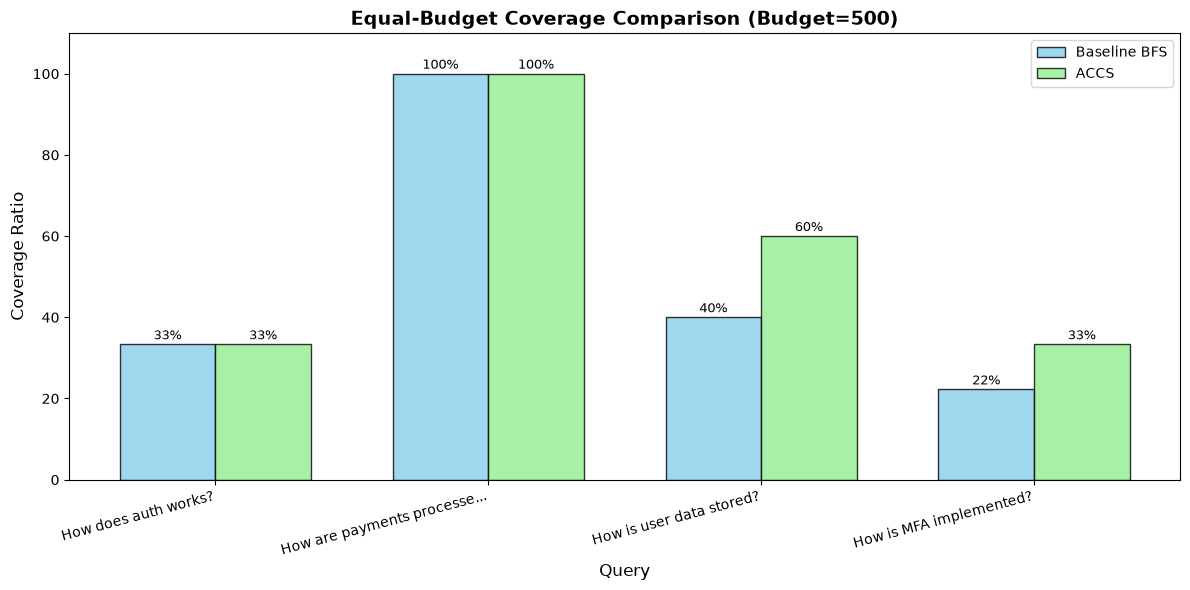

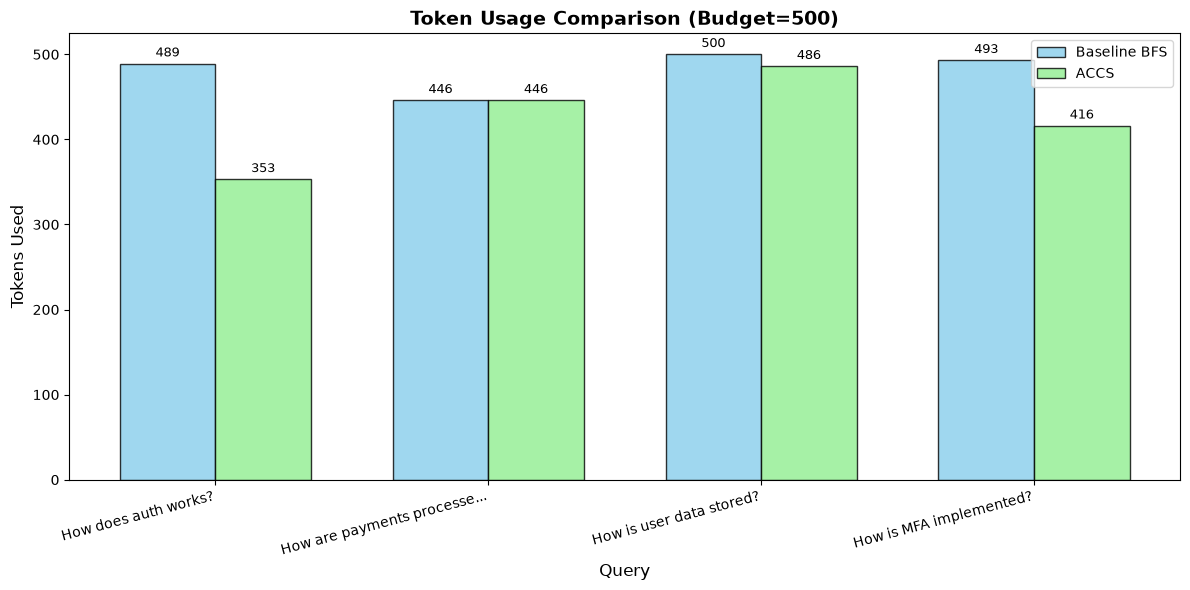

In [24]:
# Equal-budget comparison visualization
# -------------------------------------------------------------------------
# Prepare data
# -------------------------------------------------------------------------

labels = [
    q[:25] + "..." if len(q) > 25 else q
    for q in valid_queries
]

x = range(len(valid_queries))
width = 0.35

bfs_covs = [
    r["bfs_coverage"] * 100
    for r in equal_budget_results
]

accs_covs = [
    r["accs_coverage"] * 100
    for r in equal_budget_results
]

bfs_toks = [
    r["bfs_tokens"]
    for r in equal_budget_results
]

accs_toks = [
    r["accs_tokens"]
    for r in equal_budget_results
]


# -------------------------------------------------------------------------
# Plot 1: Coverage comparison
# -------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(
    [i - width / 2 for i in x],
    bfs_covs,
    width,
    label="Baseline BFS",
    color="skyblue",
    edgecolor="black",
    alpha=0.8,
)

bars2 = ax.bar(
    [i + width / 2 for i in x],
    accs_covs,
    width,
    label="ACCS",
    color="lightgreen",
    edgecolor="black",
    alpha=0.8,
)


# Add value labels
for bar, val in zip(bars1, bfs_covs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{val:.0f}%",
        ha="center",
        va="bottom",
        fontsize=9,
    )


for bar, val in zip(bars2, accs_covs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{val:.0f}%",
        ha="center",
        va="bottom",
        fontsize=9,
    )


# Configure plot
ax.set_title(
    f"Equal-Budget Coverage Comparison (Budget={BUDGET})",
    fontsize=14,
    fontweight="bold",
)

ax.set_xlabel("Query", fontsize=12)
ax.set_ylabel("Coverage Ratio", fontsize=12)

ax.set_xticks(list(x))
ax.set_xticklabels(
    labels,
    rotation=15,
    ha="right",
)

ax.legend()
ax.set_ylim(0, 110)

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "equal_budget_coverage.png",
    dpi=150,
    bbox_inches="tight",
)

print(
    "Coverage comparison plot saved to: "
    "equal_budget_coverage.png"
)


# -------------------------------------------------------------------------
# Plot 2: Token usage comparison
# -------------------------------------------------------------------------

fig2, ax2 = plt.subplots(figsize=(12, 6))

bars1 = ax2.bar(
    [i - width / 2 for i in x],
    bfs_toks,
    width,
    label="Baseline BFS",
    color="skyblue",
    edgecolor="black",
    alpha=0.8,
)

bars2 = ax2.bar(
    [i + width / 2 for i in x],
    accs_toks,
    width,
    label="ACCS",
    color="lightgreen",
    edgecolor="black",
    alpha=0.8,
)


# Add value labels
for bar, val in zip(bars1, bfs_toks):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{val:.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )


for bar, val in zip(bars2, accs_toks):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{val:.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )


# Configure plot
ax2.set_title(
    f"Token Usage Comparison (Budget={BUDGET})",
    fontsize=14,
    fontweight="bold",
)

ax2.set_xlabel("Query", fontsize=12)
ax2.set_ylabel("Tokens Used", fontsize=12)

ax2.set_xticks(list(x))
ax2.set_xticklabels(
    labels,
    rotation=15,
    ha="right",
)

ax2.legend()

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "equal_budget_tokens.png",
    dpi=150,
    bbox_inches="tight",
)

print(
    "Token usage plot saved to: "
    "equal_budget_tokens.png"
)